In [1]:
import EOSutils as meos

import numpy as np
import matplotlib.pyplot as plt

import matplotlib.style
import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.cm as cmx
from mpl_toolkits.axes_grid1 import make_axes_locatable
import mpltern


mpl.style.use('classic')

from astropy.table import Table
from astropy import units as u
from astropy.constants import G

import mesa_helper as mh
import os
import shutil
import copy

from scipy import interpolate,ndimage
from scipy.linalg import lstsq as scipy_lstsq
from scipy.ndimage import gaussian_filter
import scipy.integrate as integrate
import decimal 

%matplotlib inline

In [2]:
def runtime_eos_data(filename,X,species='H',plot_consistency_metrics=True,plot_tracks=True):
    """
    reads in a file with columns log10Rho   log10T  log10P log10S log10E  dpe   dse   dsp   dpe2 dse2 dsp2
    and plots.
    """

    data = np.genfromtxt(filename,skip_header=1)

    nT = 120
    nrho = 280

    rho_trunc_grid = np.round(np.reshape(data[:,0],(nT,nrho)).T,2)
    T_trunc_grid = np.round(np.reshape(data[:,1],(nT,nrho)).T,2)
    
    log10P = np.reshape(data[:,2],(nT,nrho)).T
    log10S = np.reshape(data[:,3],(nT,nrho)).T
    log10E = np.reshape(data[:,4],(nT,nrho)).T

    dpe = np.reshape(data[:,5],(nT,nrho)).T
    dse = np.reshape(data[:,6],(nT,nrho)).T
    dsp = np.reshape(data[:,7],(nT,nrho)).T

    dpe2 = np.reshape(data[:,8],(nT,nrho)).T
    dse2 = np.reshape(data[:,9],(nT,nrho)).T
    dsp2 = np.reshape(data[:,10],(nT,nrho)).T


    rho_trunc = np.arange(-8,5.96,0.05)
    T_trunc = np.arange(2.0,7.96,0.05)

    interp_P = interpolate.RegularGridInterpolator(points=(rho_trunc, T_trunc), values=log10P, bounds_error=False, fill_value=None, method='linear')
    interp_S = interpolate.RegularGridInterpolator(points=(rho_trunc, T_trunc), values=log10S, bounds_error=False, fill_value=None, method='linear')
    interp_E = interpolate.RegularGridInterpolator(points=(rho_trunc, T_trunc), values=log10E, bounds_error=False, fill_value=None, method='linear')


    interp_dpe = interpolate.RegularGridInterpolator(points=(rho_trunc, T_trunc), values=dpe, bounds_error=False, fill_value=None, method='slinear')
    interp_dse = interpolate.RegularGridInterpolator(points=(rho_trunc, T_trunc), values=dse, bounds_error=False, fill_value=None, method='slinear')
    interp_dsp = interpolate.RegularGridInterpolator(points=(rho_trunc, T_trunc), values=dsp, bounds_error=False, fill_value=None, method='slinear')

    
    interp_dpe2 = interpolate.RegularGridInterpolator(points=(rho_trunc, T_trunc), values=dpe2, bounds_error=False, fill_value=None, method='slinear')
    interp_dse2 = interpolate.RegularGridInterpolator(points=(rho_trunc, T_trunc), values=dse2, bounds_error=False, fill_value=None, method='slinear')
    interp_dsp2 = interpolate.RegularGridInterpolator(points=(rho_trunc, T_trunc), values=dsp2, bounds_error=False, fill_value=None, method='slinear')

    grid_rho = np.arange(-8,6.01,0.05)
    grid_T = np.arange(2.0,8.01,0.05)
    meshgrid_T, meshgrid_rho = np.meshgrid(grid_T, grid_rho, indexing='xy')

    log10P = interp_P((meshgrid_rho,meshgrid_T))
    log10S = interp_S((meshgrid_rho,meshgrid_T))
    log10E = interp_E((meshgrid_rho,meshgrid_T))

    dpe = interp_dpe((meshgrid_rho,meshgrid_T))
    dse = interp_dse((meshgrid_rho,meshgrid_T))
    dsp = interp_dsp((meshgrid_rho,meshgrid_T))

    dpe2 = interp_dpe2((meshgrid_rho,meshgrid_T))
    dse2 = interp_dse2((meshgrid_rho,meshgrid_T))
    dsp2 = interp_dsp2((meshgrid_rho,meshgrid_T))

    if plot_consistency_metrics is True:
        atomic_number = X + 2*(1.-X)
        mass_number = X + 4*(1.-X)
    
        if species=='H':
            # hydrogen table
            boundary = 3.3 + 0.5*meshgrid_rho + np.log10(atomic_number) - (5./3)*np.log10(mass_number)
            mask = (meshgrid_T < boundary) #| (meshgrid_T < -7.9)
        elif species=='He':  
            # helium table
            boundary = 3.3 + 0.5*meshgrid_rho + np.log10(atomic_number) - (5./3)*np.log10(mass_number)
            mask = (meshgrid_T < boundary) #| (meshgrid_T < 2.3) | (meshgrid_rho < -7.7)
        elif species=='Z' or species=='None':
            boundary = 3.3 + 0.5*meshgrid_rho + np.log10(atomic_number) - (5./3)*np.log10(mass_number)
            mask = (meshgrid_T < boundary)
    
        allowedMask = ~mask
        
        dpe = np.ma.array(dpe, mask=~allowedMask, fill_value = np.nan)
        dse = np.ma.array(dse, mask=~allowedMask, fill_value = np.nan)
        dsp = np.ma.array(dsp, mask=~allowedMask, fill_value = np.nan)

        dpe2 = np.ma.array(dpe2, mask=~allowedMask, fill_value = np.nan)
        dse2 = np.ma.array(dse2, mask=~allowedMask, fill_value = np.nan)
        dsp2 = np.ma.array(dsp2, mask=~allowedMask, fill_value = np.nan)
    
        cmap = copy.copy(mpl.cm.get_cmap("coolwarm"))
        #cmap.set_over('#A1212A')
        #cmap.set_under('#2A337E')
        cmap.set_over('#B40426')
        cmap.set_under('#3B4CC0')
        cmap.set_bad('grey')
        
        fig, axes = plt.subplots(1,3,figsize=(24,6))
            
        divider00 = make_axes_locatable(axes[0])
        cax00 = divider00.append_axes('right', size='5%', pad=0.05)
        cs00 = axes[0].pcolormesh(meshgrid_rho, meshgrid_T, np.log10(np.abs(dpe)), cmap=cmap, shading='nearest',vmin=-4,vmax=0)
        cb00 = fig.colorbar(cs00, cax=cax00, orientation='vertical',label=r'$\log_{10}{|\mathrm{dpe}|}$',ticks=[-4,-3,-2,-1,0])
        cb00.set_label(label=r'$\log_{10}{|\mathrm{dpe}|}$',size=25)
        cb00.ax.tick_params(labelsize=25) 
            
        divider01 = make_axes_locatable(axes[1])
        cax01 = divider01.append_axes('right', size='5%', pad=0.05)
        cs01 = axes[1].pcolormesh(meshgrid_rho, meshgrid_T, np.log10(np.abs(dse)), cmap=cmap, shading='nearest',vmin=-4,vmax=0)
        cb01 = fig.colorbar(cs01, cax=cax01, orientation='vertical',label=r'$\log_{10}{|\mathrm{dse}|}$',ticks=[-4,-3,-2,-1,0])
        cb01.set_label(label=r'$\log_{10}{|\mathrm{dse}|}$',size=25)
        cb01.ax.tick_params(labelsize=25) 
    
        divider02 = make_axes_locatable(axes[2])
        cax02 = divider02.append_axes('right', size='5%', pad=0.05)
        cs02 = axes[2].pcolormesh(meshgrid_rho, meshgrid_T, np.log10(np.abs(dsp)), cmap=cmap, shading='nearest',vmin=-4,vmax=0)
        cb02 = fig.colorbar(cs02, cax=cax02, orientation='vertical',label=r'$\log_{10}{|\mathrm{dsp}|}$',ticks=[-4,-3,-2,-1,0])
        cb02.set_label(label=r'$\log_{10}{|\mathrm{dsp}|}$',size=25)
        cb02.ax.tick_params(labelsize=25) 
            
        for ax in axes:
            ax.set_xlim(-8,6)
            ax.set_ylim(2,8)
            ax.set_xlabel(r'$\log_{10}{\rho\ [\mathrm{g/cm}^3]}$',fontsize=35)
            ax.tick_params(axis='both', which='major', labelsize=25)
            if plot_tracks is True:
                profiles = meos.load_sample_planet_profiles(Minit=np.array((1.09,7.59,20.0)), Rinit=2.0, Zinit=0.025, comps=['uniform','inert_core'], Sinit=np.array((9.0,11.0)), alphas=2.0, ages=np.array((1.e6,1.e10)))
    
                for prof in profiles:
                    ax.plot(prof['logRho'], prof['logT'],ls='-',color='#7FFF00')
        axes[0].set_ylabel(r'$\log_{10}{T\ [\mathrm{K}]}$',fontsize=35)
        
        plt.subplots_adjust(wspace=0.3)
        plt.show()

        fig, axes = plt.subplots(1,3,figsize=(24,6))

        divider10 = make_axes_locatable(axes[0])
        cax10 = divider10.append_axes('right', size='5%', pad=0.05)
        cs10 = axes[0].pcolormesh(meshgrid_rho, meshgrid_T, np.log10(np.abs(dpe2)), cmap=cmap, shading='nearest',vmin=-4,vmax=0)
        cb10 = fig.colorbar(cs10, cax=cax10, orientation='vertical',label=r'$\log_{10}{|\mathrm{dpe}|}$',ticks=[-4,-3,-2,-1,0])
        cb10.set_label(label=r'$\log_{10}{|\mathrm{dpe}|}$',size=25)
        cb10.ax.tick_params(labelsize=25) 
            
        divider11 = make_axes_locatable(axes[1])
        cax11 = divider11.append_axes('right', size='5%', pad=0.05)
        cs11 = axes[1].pcolormesh(meshgrid_rho, meshgrid_T, np.log10(np.abs(dse2)), cmap=cmap, shading='nearest',vmin=-4,vmax=0)
        cb11 = fig.colorbar(cs11, cax=cax11, orientation='vertical',label=r'$\log_{10}{|\mathrm{dse}|}$',ticks=[-4,-3,-2,-1,0])
        cb11.set_label(label=r'$\log_{10}{|\mathrm{dse}|}$',size=25)
        cb11.ax.tick_params(labelsize=25) 
    
        divider12 = make_axes_locatable(axes[2])
        cax12 = divider12.append_axes('right', size='5%', pad=0.05)
        cs12 = axes[2].pcolormesh(meshgrid_rho, meshgrid_T, np.log10(np.abs(dsp2)), cmap=cmap, shading='nearest',vmin=-4,vmax=0)
        cb12 = fig.colorbar(cs12, cax=cax12, orientation='vertical',label=r'$\log_{10}{|\mathrm{dsp}|}$',ticks=[-4,-3,-2,-1,0])
        cb12.set_label(label=r'$\log_{10}{|\mathrm{dsp}|}$',size=25)
        cb12.ax.tick_params(labelsize=25) 
            
        for ax in np.ravel(axes):
            ax.set_xlim(-8,6)
            ax.set_ylim(2,8)
            ax.set_xlabel(r'$\log_{10}{\rho\ [\mathrm{g/cm}^3]}$',fontsize=35)
            ax.tick_params(axis='both', which='major', labelsize=25)
            if plot_tracks is True:
                profiles = meos.load_sample_planet_profiles(Minit=np.array((1.09,7.59,20.0)), Rinit=2.0, Zinit=0.025, comps=['uniform','inert_core'], Sinit=np.array((9.0,11.0)), alphas=2.0, ages=np.array((1.e6,1.e10)))
    
                for prof in profiles:
                    ax.plot(prof['logRho'], prof['logT'],ls='-',color='#7FFF00')
        axes[0].set_ylabel(r'$\log_{10}{T\ [\mathrm{K}]}$',fontsize=35)
        
        plt.subplots_adjust(wspace=0.3)
        plt.show()
    
    return log10P, log10S, log10E, dpe, dse, dsp, dpe2, dse2, dsp2
    

In [3]:
#profiles = meos.load_sample_planet_profiles(Minit=np.array((1.09,7.59,20.0)), Rinit=2.0, Zinit=0.025, comps=['uniform','inert_core'], Sinit=np.array((9.0,11.0)), alphas=2.0, ages=np.array((1.e6,1.e10)))
profiles = meos.load_sample_planet_profiles(Minit=np.array((1.09,2.88,7.59,20.0)), Rinit=2.0, Zinit=0.025, comps=['uniform'], Sinit=np.array((9.0)), alphas=2.0, ages=np.array((1.e7,1.e10)))


In [4]:
'''
compstr = '00z100x'
XX = 1.0
YY = 0.0
ZZ = 0.0
'''
compstr = 'protosolar'
XX = 0.706
YY = 0.277
ZZ = 0.017

orig_tabulated_QT = meos.read_MESAtable("../meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend_{0}.data".format(compstr))

orig_tabulated_rhoT, orig_tabulated = meos.reshapeQTgrid(orig_tabulated_QT,lower_logRho_bound=-8,upper_logRho_bound=6,rounding=2)
orig_tabulated.X = XX
orig_tabulated.Y = YY
orig_tabulated.Z = ZZ
orig_tabulated.compute_atomic_number()


TC_tabulated_QT = meos.read_MESAtable("../meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend-TC_s=2_{0}.data".format(compstr))

TC_tabulated_rhoT, TC_tabulated = meos.reshapeQTgrid(TC_tabulated_QT,lower_logRho_bound=-8,upper_logRho_bound=6,rounding=2)
TC_tabulated.X = XX
TC_tabulated.Y = YY
TC_tabulated.Z = ZZ
TC_tabulated.compute_atomic_number()


/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1493: UserWarning: The following kwargs were not used by contour: 'shading'
  cs = axes[i,j].contourf(xs[i*nCol + j], ys[i*nCol + j], zs[i*nCol + j], shading='nearest', cmap=cmap[i*nCol + j], levels=np.linspace(zlims[i*nCol+j][0],zlims[i*nCol+j][1],levels[i*nCol+j]))


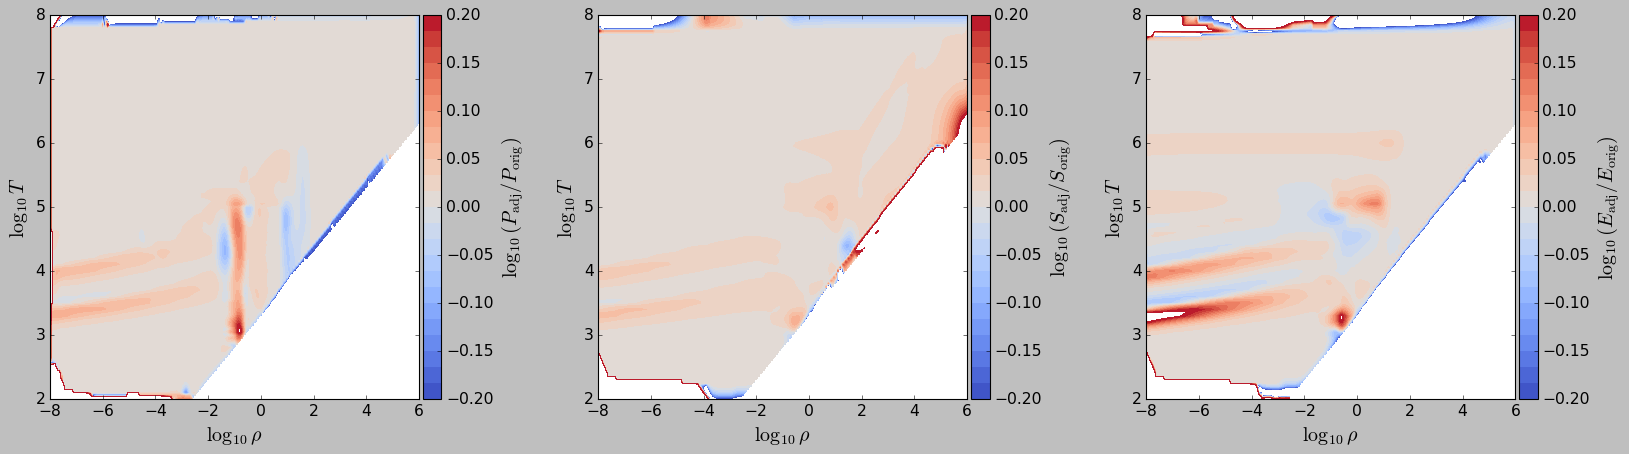

In [5]:
meos.contourf_subplots_with_colorbars(nRow=1, nCol=3, 
                                xs=orig_tabulated.log10rhogrid,
                                ys=orig_tabulated.log10Tgrid,
                                zs=[np.log10(10**TC_tabulated.log10Pgrid/10**orig_tabulated.log10Pgrid),np.log10(10**TC_tabulated.log10Sgrid/10**orig_tabulated.log10Sgrid),np.log10(10**TC_tabulated.log10Egrid/10**orig_tabulated.log10Egrid)],
                                xlims=(-8,6),
                                ylims=(2,8),
                                zlims=(-0.2,0.2),
                                levels=25,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=[r'$\log_{10}{(P_\mathrm{adj}/P_\mathrm{orig})}$',r'$\log_{10}{(S_\mathrm{adj}/S_\mathrm{orig})}$',r'$\log_{10}{(E_\mathrm{adj}/E_\mathrm{orig})}$'],
                                cmap='coolwarm', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, 
                                species='H', plot_interpolation_lines=False, savename=None)#savename="./paper_figures/PSEchange_{0}.pdf".format(compstr))

meos.contourf_subplots_with_colorbars(nRow=1, nCol=3, 
                                xs=orig_tabulated.log10rhogrid,
                                ys=orig_tabulated.log10Tgrid,
                                zs=[10**TC_tabulated.log10Pgrid/10**orig_tabulated.log10Pgrid,10**TC_tabulated.log10Sgrid/10**orig_tabulated.log10Sgrid,10**TC_tabulated.log10Egrid/10**orig_tabulated.log10Egrid],
                                xlims=(-8,6),
                                ylims=(2,8),
                                zlims=(0.5,1.5),
                                levels=25,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=[r'${(P_\mathrm{adj}/P_\mathrm{orig})}$',r'${(S_\mathrm{adj}/S_\mathrm{orig})}$',r'${(E_\mathrm{adj}/E_\mathrm{orig})}$'],
                                cmap='coolwarm', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, 
                                species='H', plot_interpolation_lines=False, savename="./paper_figures/PSEchange_{0}.pdf".format(compstr))



In [27]:
meos.contourf_subplots_with_colorbars(nRow=1, nCol=1, 
                                xs=orig_tabulated.log10rhogrid,
                                ys=orig_tabulated.log10Tgrid,
                                zs=[np.log10(np.abs(10**orig_tabulated.log10Egrid - 10**orig_tabulated.log10Tgrid*10**orig_tabulated.log10Sgrid))],
                                xlims=(-8,6),
                                ylims=(2,8),
                                zlims=None,
                                levels=25,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=[r'$\log_{10}|F|$'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, 
                                species='H', plot_interpolation_lines=False, savename="./paper_figures/F_{0}.pdf".format(compstr))


In [29]:
meos.contourf_subplots_with_colorbars(nRow=1, nCol=4, 
                                xs=orig_tabulated.log10rhogrid,
                                ys=orig_tabulated.log10Tgrid,
                                zs=[orig_tabulated.log10Pgrid,orig_tabulated.log10Sgrid,orig_tabulated.log10Egrid,np.log10(np.abs(10**orig_tabulated.log10Egrid - 10**orig_tabulated.log10Tgrid*10**orig_tabulated.log10Sgrid))],
                                xlims=(-8,6),
                                ylims=(2,8),
                                zlims=None,
                                levels=25,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=[r'$\log_{10}P$',r'$\log_{10}S$',r'$\log_{10}E$',r'$\log_{10}|F|$'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, 
                                species='H', plot_interpolation_lines=False, savename="./paper_figures/PSEF_{0}.pdf".format(compstr))


In [31]:
meos.contourf_subplots_with_colorbars(nRow=1, nCol=4, 
                                xs=TC_tabulated.log10rhogrid,
                                ys=TC_tabulated.log10Tgrid,
                                zs=[TC_tabulated.log10Pgrid,TC_tabulated.log10Sgrid,TC_tabulated.log10Egrid,np.log10(np.abs(10**TC_tabulated.log10Egrid - 10**TC_tabulated.log10Tgrid*10**TC_tabulated.log10Sgrid))],
                                xlims=(-8,6),
                                ylims=(2,8),
                                zlims=[(1,23),(8,10),(9.9,17.1),(9.2,18)],
                                levels=25,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=[r'$\log_{10}P$',r'$\log_{10}S$',r'$\log_{10}E$',r'$\log_{10}|F|$'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, 
                                species='H', plot_interpolation_lines=False, savename="./paper_figures/TC_PSEF_{0}.pdf".format(compstr))


/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1493: UserWarning: The following kwargs were not used by contour: 'shading'
  cs = axes[i,j].contourf(xs[i*nCol + j], ys[i*nCol + j], zs[i*nCol + j], shading='nearest', cmap=cmap[i*nCol + j], levels=np.linspace(zlims[i*nCol+j][0],zlims[i*nCol+j][1],levels[i*nCol+j]))


In [6]:
print(len(profiles))

8


In [7]:
savenamestr = "CMS19_orig_meos_implementation"
#orig_tabulated_dpe, orig_tabulated_dse, orig_tabulated_dsp, orig_tabulated_a, orig_tabulated_b, orig_tabulated_c = meos.consistency_metrics(orig_tabulated, P=10**orig_tabulated.log10Pgrid,S=10**orig_tabulated.log10Sgrid,E=10**orig_tabulated.log10Egrid,species='H',order=6,maskUnphysicalRegion=True,paperplot=True,plot_tracks=True,profiles=profiles,savename="./paper_figures/{0}_{1}_withtracks.pdf".format(savenamestr,compstr))
#orig_tabulated_dpe, orig_tabulated_dse, orig_tabulated_dsp, orig_tabulated_a, orig_tabulated_b, orig_tabulated_c = meos.consistency_metrics(orig_tabulated, P=10**orig_tabulated.log10Pgrid,S=10**orig_tabulated.log10Sgrid,E=10**orig_tabulated.log10Egrid,species='H',order=6,maskUnphysicalRegion=True,paperplot=True,plot_tracks=False,profiles=profiles,savename="./paper_figures/{0}_{1}.pdf".format(savenamestr,compstr))

#orig_tabulated_dpe, orig_tabulated_dse, orig_tabulated_dsp, orig_tabulated_a, orig_tabulated_b, orig_tabulated_c = meos.consistency_metrics(orig_tabulated, P=10**orig_tabulated.log10Pgrid,S=10**orig_tabulated.log10Sgrid,E=10**orig_tabulated.log10Egrid,species='H',order=6,maskUnphysicalRegion=True,paperplot=True,plot_tracks=True,profiles=profiles,savename="./paper_figures/{0}_{1}.png".format(savenamestr,compstr))
orig_tabulated_dpe, orig_tabulated_dse, orig_tabulated_dsp, orig_tabulated_a, orig_tabulated_b, orig_tabulated_c = meos.consistency_metrics(orig_tabulated, P=10**orig_tabulated.log10Pgrid,S=10**orig_tabulated.log10Sgrid,E=10**orig_tabulated.log10Egrid,species='H',order=6,maskUnphysicalRegion=True,paperplot=False,plot_tracks=False,savename=None)

fig,axes = plt.subplots(1,3,figsize=(24,6))

for ax in axes:
    ax.set_ylim(-6,0)
    ax.set_xlabel(r"$m/M_P$",fontsize=24)

#smoothing = np.array((1,2,5))
#scalingfac = np.array((0.05,0.1,0.25))
smoothing = np.atleast_1d(np.array((1)))
scalingfac = np.atleast_1d(np.array((0.1)))

scolors = ['#2C33F3','#656AF6','#9FA2F9']
sfls = ['--','-.',':']
for i,s in enumerate(smoothing):
    tcstr = "CMS19_TC_s={0}".format(s)

    TC_tabulated_QT = meos.read_MESAtable("../meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend-TC_s={0}_{1}.data".format(s,compstr))

    TC_tabulated_rhoT, TC_tabulated = meos.reshapeQTgrid(TC_tabulated_QT,lower_logRho_bound=-8,upper_logRho_bound=6,rounding=2)
    TC_tabulated.X = XX
    TC_tabulated.Y = YY
    TC_tabulated.Z = ZZ
    TC_tabulated.compute_atomic_number()
    #TC_tabulated_dpe, TC_tabulated_dse, TC_tabulated_dsp, TC_tabulated_a, TC_tabulated_b, TC_tabulated_c = meos.consistency_metrics(TC_tabulated, P=10**TC_tabulated.log10Pgrid,S=10**TC_tabulated.log10Sgrid,E=10**TC_tabulated.log10Egrid,species='H',order=6,maskUnphysicalRegion=True,paperplot=True,plot_tracks=True,profiles=profiles,savename="./paper_figures/{0}_{1}_withtracks.pdf".format(tcstr,compstr))
    #TC_tabulated_dpe, TC_tabulated_dse, TC_tabulated_dsp, TC_tabulated_a, TC_tabulated_b, TC_tabulated_c = meos.consistency_metrics(TC_tabulated, P=10**TC_tabulated.log10Pgrid,S=10**TC_tabulated.log10Sgrid,E=10**TC_tabulated.log10Egrid,species='H',order=6,maskUnphysicalRegion=True,paperplot=True,plot_tracks=False,profiles=profiles,savename="./paper_figures/{0}_{1}.pdf".format(tcstr,compstr))
    
    #TC_tabulated_dpe, TC_tabulated_dse, TC_tabulated_dsp, TC_tabulated_a, TC_tabulated_b, TC_tabulated_c = meos.consistency_metrics(TC_tabulated, P=10**TC_tabulated.log10Pgrid,S=10**TC_tabulated.log10Sgrid,E=10**TC_tabulated.log10Egrid,species='H',order=6,maskUnphysicalRegion=True,paperplot=True,plot_tracks=True,profiles=profiles,savename="./paper_figures/{0}_{1}.png".format(tcstr,compstr))
    TC_tabulated_dpe, TC_tabulated_dse, TC_tabulated_dsp, TC_tabulated_a, TC_tabulated_b, TC_tabulated_c = meos.consistency_metrics(TC_tabulated, P=10**TC_tabulated.log10Pgrid,S=10**TC_tabulated.log10Sgrid,E=10**TC_tabulated.log10Egrid,species='H',order=6,maskUnphysicalRegion=True,paperplot=False,plot_tracks=False,savename=None)

    for ii,p in enumerate(profiles):
        orig_dpe_ap = meos.along_profile(np.log10(np.abs(TC_tabulated_dpe)), p)
        orig_dse_ap = meos.along_profile(np.log10(np.abs(TC_tabulated_dse)), p)
        orig_dsp_ap = meos.along_profile(np.log10(np.abs(TC_tabulated_dsp)), p)
        #orig_dpe_ap = meos.along_profile(TC_tabulated_dpe, p)
        #orig_dse_ap = meos.along_profile(TC_tabulated_dse, p)
        #orig_dsp_ap = meos.along_profile(TC_tabulated_dsp, p)
        if ii==0:
            axes[0].plot(p['q'],orig_dpe_ap,color=scolors[i],ls='-',lw=1.5,label='F-derived EoS')
        else:
            axes[0].plot(p['q'],orig_dpe_ap,color=scolors[i],ls='-',lw=1.5)
        axes[1].plot(p['q'],orig_dse_ap,color=scolors[i],ls='-',lw=1.5)
        axes[2].plot(p['q'],orig_dsp_ap,color=scolors[i],ls='-',lw=1.5)

for i,s in enumerate(smoothing):
    for j,sf in enumerate(scalingfac):
        tcstr = "CMS19_control_s={0}_sf={1}".format(s,sf)

        TC_tabulated_QT = meos.read_MESAtable("../meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend-control_s={0}_sf={1}_{2}.data".format(s,sf,compstr))
    
        TC_tabulated_rhoT, TC_tabulated = meos.reshapeQTgrid(TC_tabulated_QT,lower_logRho_bound=-8,upper_logRho_bound=6,rounding=2)
        TC_tabulated.X = XX
        TC_tabulated.Y = YY
        TC_tabulated.Z = ZZ
        TC_tabulated.compute_atomic_number()
        #TC_tabulated_dpe, TC_tabulated_dse, TC_tabulated_dsp, TC_tabulated_a, TC_tabulated_b, TC_tabulated_c = meos.consistency_metrics(TC_tabulated, P=10**TC_tabulated.log10Pgrid,S=10**TC_tabulated.log10Sgrid,E=10**TC_tabulated.log10Egrid,species='H',order=6,maskUnphysicalRegion=True,paperplot=True,plot_tracks=True,profiles=profiles,savename="./paper_figures/{0}_{1}_withtracks.pdf".format(tcstr,compstr))
        #TC_tabulated_dpe, TC_tabulated_dse, TC_tabulated_dsp, TC_tabulated_a, TC_tabulated_b, TC_tabulated_c = meos.consistency_metrics(TC_tabulated, P=10**TC_tabulated.log10Pgrid,S=10**TC_tabulated.log10Sgrid,E=10**TC_tabulated.log10Egrid,species='H',order=6,maskUnphysicalRegion=True,paperplot=True,plot_tracks=False,profiles=profiles,savename="./paper_figures/{0}_{1}.pdf".format(tcstr,compstr))

        #TC_tabulated_dpe, TC_tabulated_dse, TC_tabulated_dsp, TC_tabulated_a, TC_tabulated_b, TC_tabulated_c = meos.consistency_metrics(TC_tabulated, P=10**TC_tabulated.log10Pgrid,S=10**TC_tabulated.log10Sgrid,E=10**TC_tabulated.log10Egrid,species='H',order=6,maskUnphysicalRegion=True,paperplot=True,plot_tracks=True,profiles=profiles,savename="./paper_figures/{0}_{1}.png".format(tcstr,compstr))
        TC_tabulated_dpe, TC_tabulated_dse, TC_tabulated_dsp, TC_tabulated_a, TC_tabulated_b, TC_tabulated_c = meos.consistency_metrics(TC_tabulated, P=10**TC_tabulated.log10Pgrid,S=10**TC_tabulated.log10Sgrid,E=10**TC_tabulated.log10Egrid,species='H',order=6,maskUnphysicalRegion=True,paperplot=False,plot_tracks=False,savename=None)
        
        for p in profiles:
            orig_dpe_ap = meos.along_profile(np.log10(np.abs(TC_tabulated_dpe)), p)
            orig_dse_ap = meos.along_profile(np.log10(np.abs(TC_tabulated_dse)), p)
            orig_dsp_ap = meos.along_profile(np.log10(np.abs(TC_tabulated_dsp)), p)
            #orig_dpe_ap = meos.along_profile(TC_tabulated_dpe, p)
            #orig_dse_ap = meos.along_profile(TC_tabulated_dse, p)
            #orig_dsp_ap = meos.along_profile(TC_tabulated_dsp, p)
            #axes[0].plot(p['q'],orig_dpe_ap,color=scolors[i],ls=sfls[j])
            #axes[1].plot(p['q'],orig_dse_ap,color=scolors[i],ls=sfls[j])
            #axes[2].plot(p['q'],orig_dsp_ap,color=scolors[i],ls=sfls[j])


for ii,p in enumerate(profiles):
    orig_dpe_ap = meos.along_profile(np.log10(np.abs(orig_tabulated_dpe)), p)
    orig_dse_ap = meos.along_profile(np.log10(np.abs(orig_tabulated_dse)), p)
    orig_dsp_ap = meos.along_profile(np.log10(np.abs(orig_tabulated_dsp)), p)
    #orig_dpe_ap = meos.along_profile(orig_tabulated_dpe, p)
    #orig_dse_ap = meos.along_profile(orig_tabulated_dse, p)
    #orig_dsp_ap = meos.along_profile(orig_tabulated_dsp, p)
    if ii==0:
        axes[0].plot(p['q'],orig_dpe_ap,'k-',lw=1.5,label='original EoS')
    else:
        axes[0].plot(p['q'],orig_dpe_ap,'k-',lw=1.5)
    axes[1].plot(p['q'],orig_dse_ap,'k-',lw=1.5)
    axes[2].plot(p['q'],orig_dsp_ap,'k-',lw=1.5)

axes[0].set_ylabel(r"$\log_{10}|\mathrm{dpe}|$",fontsize=24)
axes[1].set_ylabel(r"$\log_{10}|\mathrm{dse}|$",fontsize=24)
axes[2].set_ylabel(r"$\log_{10}|\mathrm{dsp}|$",fontsize=24)


axes[0].legend(loc='upper left',frameon=False)
#plt.show()
plt.savefig("./paper_figures/planet_track_consistency_{0}.pdf".format(compstr),bbox_inches='tight')


# new figure: apply bicubic interpolation to a finer (rho, T) grid; calculate metrics on the finer grid to make sure that the in-between points are still an improvement

In [13]:
print(orig_tabulated.X)
print(TC_tabulated.log10rhogrid)
print(TC_tabulated.log10Tgrid)

1.0
[[-8.   -8.   -8.   ... -8.   -8.   -8.  ]
 [-7.95 -7.95 -7.95 ... -7.95 -7.95 -7.95]
 [-7.9  -7.9  -7.9  ... -7.9  -7.9  -7.9 ]
 ...
 [ 5.9   5.9   5.9  ...  5.9   5.9   5.9 ]
 [ 5.95  5.95  5.95 ...  5.95  5.95  5.95]
 [ 6.    6.    6.   ...  6.    6.    6.  ]]
[[2.   2.05 2.1  ... 7.9  7.95 8.  ]
 [2.   2.05 2.1  ... 7.9  7.95 8.  ]
 [2.   2.05 2.1  ... 7.9  7.95 8.  ]
 ...
 [2.   2.05 2.1  ... 7.9  7.95 8.  ]
 [2.   2.05 2.1  ... 7.9  7.95 8.  ]
 [2.   2.05 2.1  ... 7.9  7.95 8.  ]]


In [5]:
def upscale_rhoT(table,upscale_factor=10,plot_tracks=False,savename=None,dpi='figure'):
    orig_rho = table.log10rhogrid[:,0]
    orig_T = table.log10Tgrid[0]
    
    #print(orig_rho, orig_T)

    hires_rho = np.linspace(orig_rho[0],orig_rho[-1],upscale_factor*len(orig_rho))
    hires_T = np.linspace(orig_T[0],orig_T[-1],upscale_factor*len(orig_T))

    hires_Tgrid, hires_rhogrid = np.meshgrid(hires_T,hires_rho)

    interp_P = interpolate.RegularGridInterpolator(points=(orig_rho, orig_T), values=meos.fill_in_nans(table.log10Pgrid, table), bounds_error=False, fill_value=None, method='cubic')
    interp_S = interpolate.RegularGridInterpolator(points=(orig_rho, orig_T), values=meos.fill_in_nans(table.log10Sgrid, table), bounds_error=False, fill_value=None, method='cubic')
    interp_E = interpolate.RegularGridInterpolator(points=(orig_rho, orig_T), values=meos.fill_in_nans(table.log10Egrid, table), bounds_error=False, fill_value=None, method='cubic')
    
    hires_Pgrid = interp_P((hires_rhogrid,hires_Tgrid))
    hires_Sgrid = interp_S((hires_rhogrid,hires_Tgrid))
    hires_Egrid = interp_E((hires_rhogrid,hires_Tgrid))

    hires_table = meos.simple_table()
    hires_table.X = table.X
    hires_table.Y = table.Y
    hires_table.Z = table.Z
    hires_table.atomic_number = table.atomic_number
    hires_table.mass_number = table.mass_number
    hires_table.log10rhogrid = hires_rhogrid
    hires_table.log10Tgrid = hires_Tgrid
    hires_table.log10Pgrid = hires_Pgrid
    hires_table.log10Sgrid = hires_Sgrid
    hires_table.log10Egrid = hires_Egrid

    hires_dpe, hires_dse, hires_dsp, hires_a, hires_b, hires_c = meos.consistency_metrics(hires_table, P=10**hires_table.log10Pgrid,S=10**hires_table.log10Sgrid,E=10**hires_table.log10Egrid,species='He',order=8,maskUnphysicalRegion=True,paperplot=True,plot_tracks=plot_tracks,savename=savename,dpi=dpi)


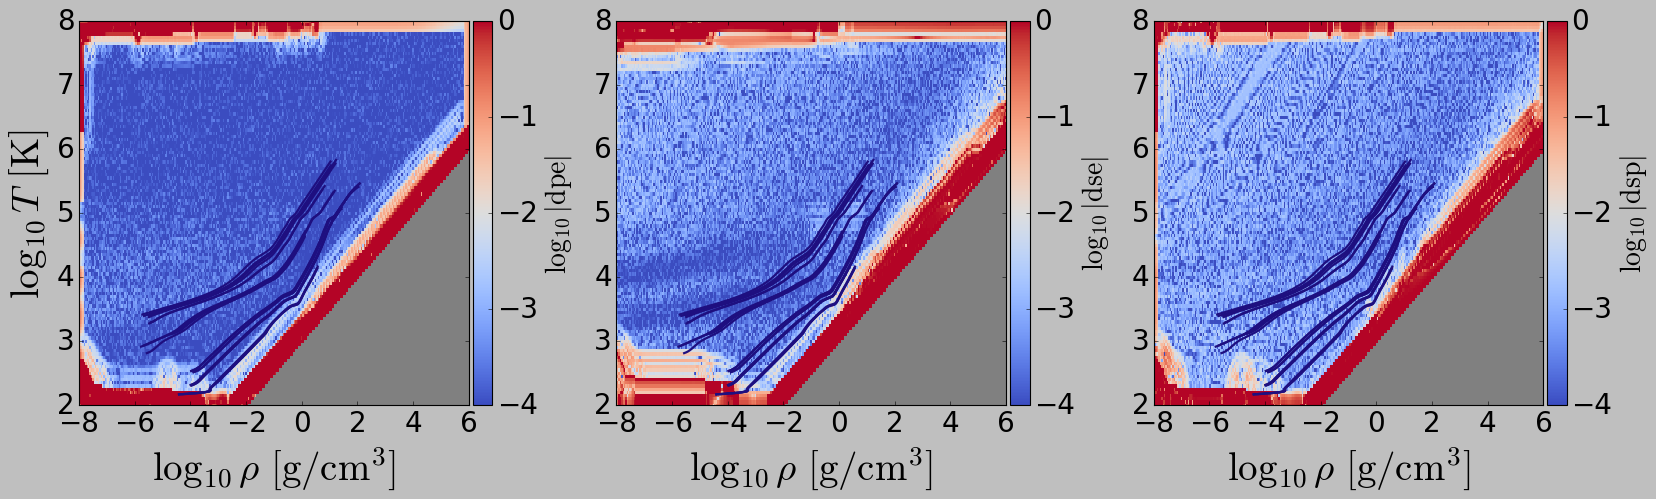

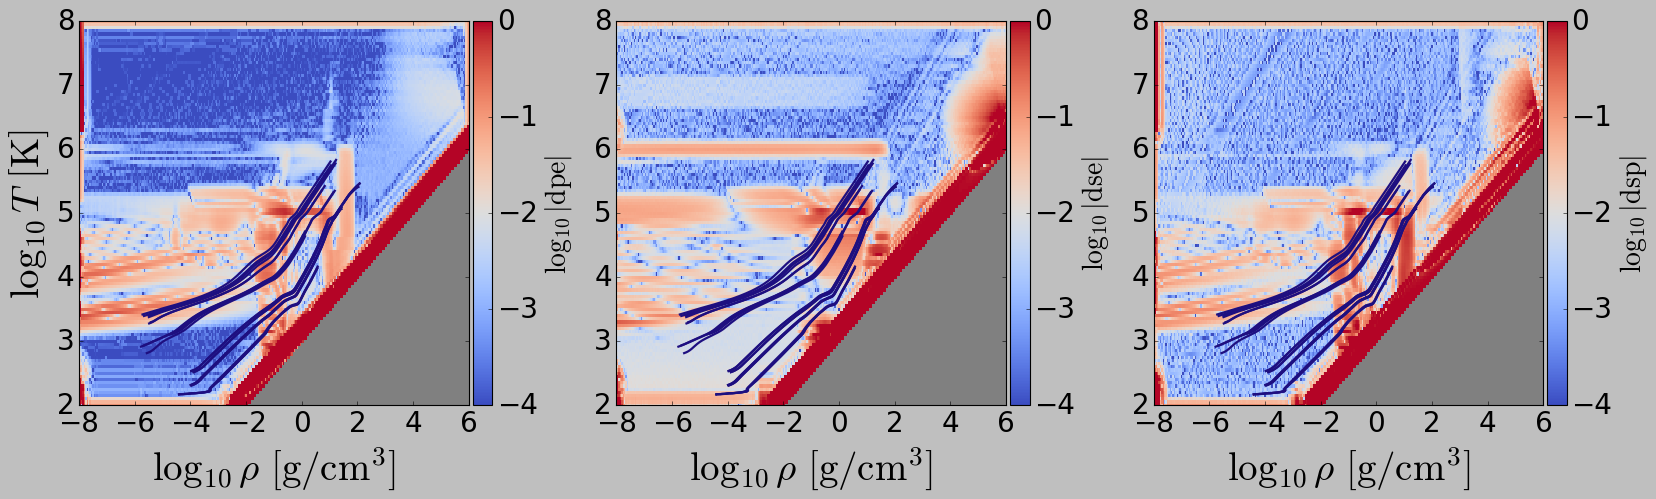

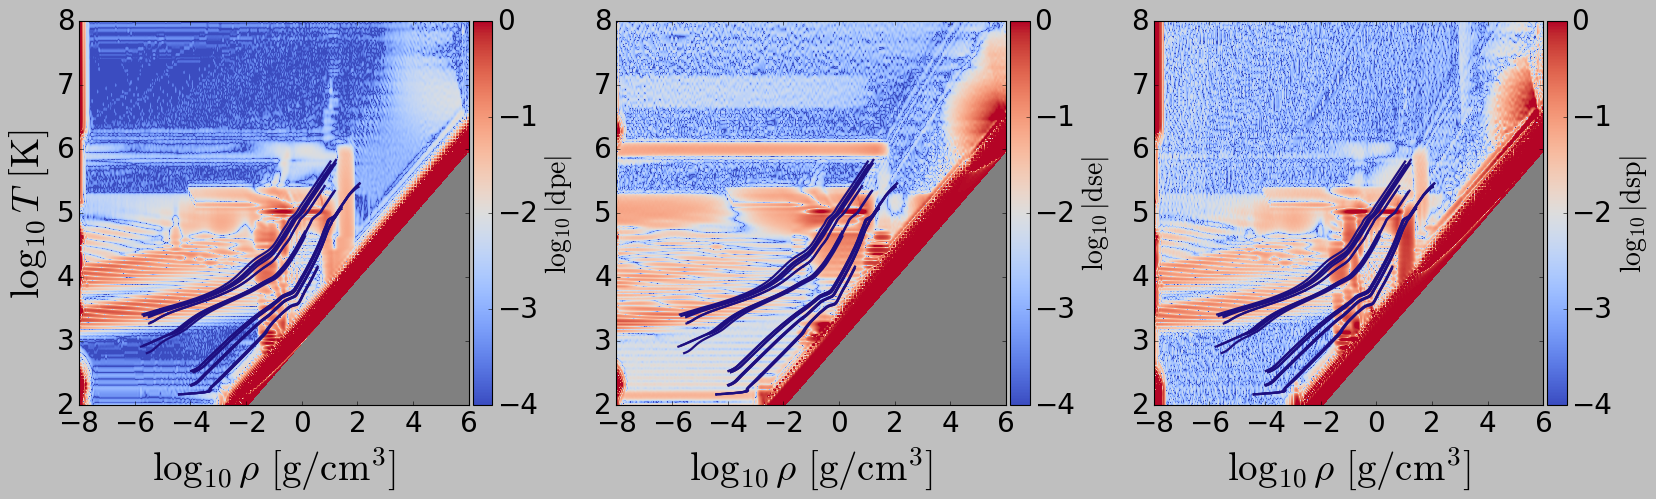

In [9]:
upscale_rhoT(orig_tabulated,upscale_factor=1,plot_tracks=True)
upscale_rhoT(orig_tabulated,upscale_factor=10,plot_tracks=True)

In [14]:
upscale_rhoT(TC_tabulated,upscale_factor=1,plot_tracks=True,savename="./paper_figures/protosolar_comp_TC_pre-upscaling.png")
upscale_rhoT(TC_tabulated,upscale_factor=10,plot_tracks=True,savename="./paper_figures/protosolar_comp_TC_upscaledx10.png")

In [12]:
from mpltern.datasets import get_spiral


fig = plt.figure(figsize=(8,6))
ax = plt.subplot(projection='ternary')
print(TC_tabulated.X +TC_tabulated.Y+TC_tabulated.Z)

ax.plot(0.706,0.277,0.017,'ro',mec='None',ms=10)
#ax.plot(t=0.1,l=0.1,r=0.1)

ax.set_tlabel("X",fontsize=25)
ax.set_llabel("Y",fontsize=25)
ax.set_rlabel("Z",fontsize=25)

ax.taxis.set_label_position('tick1')
ax.laxis.set_label_position('tick1')
ax.raxis.set_label_position('tick1')

ax.grid()
#plt.show()
plt.savefig("./paper_figures/protosolar_comp_ternary.pdf",bbox_inches='tight')

1.0


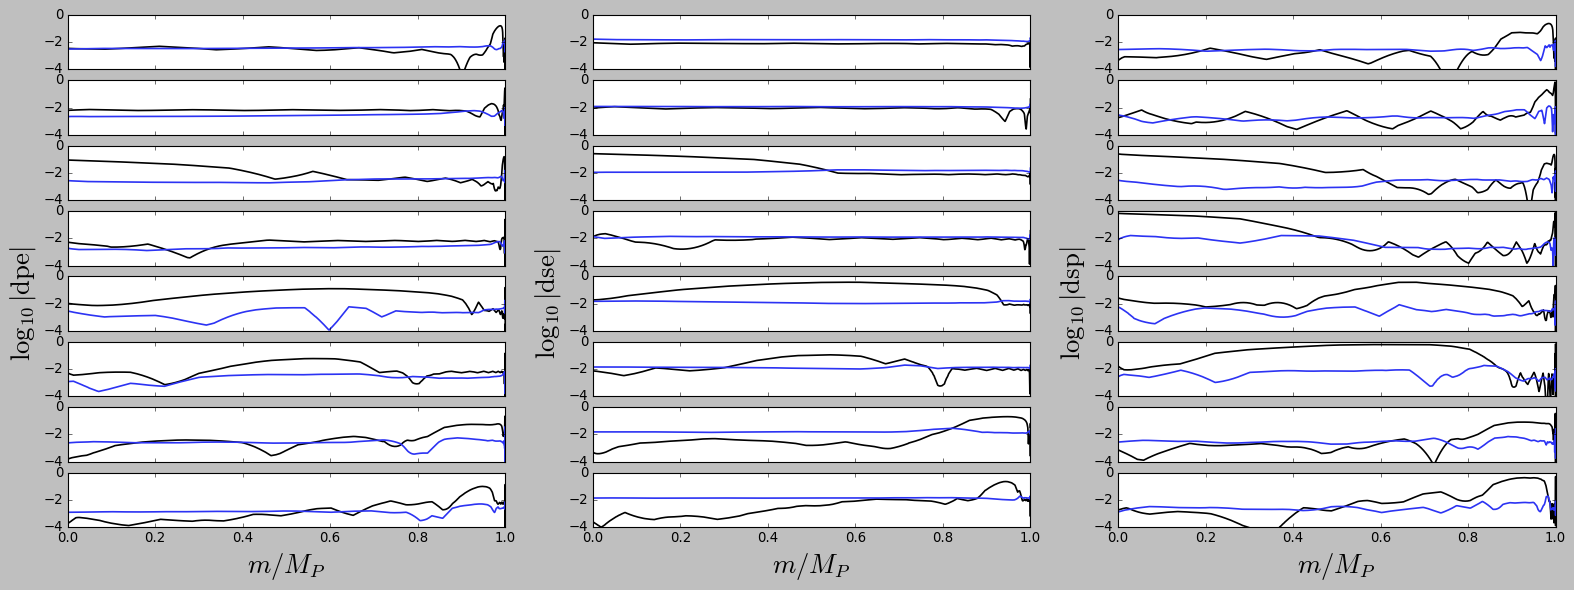

In [42]:
savenamestr = "CMS19_orig_meos_implementation"
#orig_tabulated_dpe, orig_tabulated_dse, orig_tabulated_dsp, orig_tabulated_a, orig_tabulated_b, orig_tabulated_c = meos.consistency_metrics(orig_tabulated, P=10**orig_tabulated.log10Pgrid,S=10**orig_tabulated.log10Sgrid,E=10**orig_tabulated.log10Egrid,species='H',order=6,maskUnphysicalRegion=True,paperplot=True,plot_tracks=True,profiles=profiles,savename="./paper_figures/{0}_{1}.pdf".format(savenamestr,compstr))
#orig_tabulated_dpe, orig_tabulated_dse, orig_tabulated_dsp, orig_tabulated_a, orig_tabulated_b, orig_tabulated_c = meos.consistency_metrics(orig_tabulated, P=10**orig_tabulated.log10Pgrid,S=10**orig_tabulated.log10Sgrid,E=10**orig_tabulated.log10Egrid,species='H',order=6,maskUnphysicalRegion=True,paperplot=True,plot_tracks=True,profiles=profiles,savename="./paper_figures/{0}_{1}.png".format(savenamestr,compstr))
orig_tabulated_dpe, orig_tabulated_dse, orig_tabulated_dsp, orig_tabulated_a, orig_tabulated_b, orig_tabulated_c = meos.consistency_metrics(orig_tabulated, P=10**orig_tabulated.log10Pgrid,S=10**orig_tabulated.log10Sgrid,E=10**orig_tabulated.log10Egrid,species='H',order=6,maskUnphysicalRegion=True,paperplot=False,plot_tracks=False,savename=None)

fig,axes = plt.subplots(8,3,figsize=(24,8))

for ii,p in enumerate(profiles):
    orig_dpe_ap = meos.along_profile(np.log10(np.abs(orig_tabulated_dpe)), p)
    orig_dse_ap = meos.along_profile(np.log10(np.abs(orig_tabulated_dse)), p)
    orig_dsp_ap = meos.along_profile(np.log10(np.abs(orig_tabulated_dsp)), p)
    #orig_dpe_ap = meos.along_profile(orig_tabulated_dpe, p)
    #orig_dse_ap = meos.along_profile(orig_tabulated_dse, p)
    #orig_dsp_ap = meos.along_profile(orig_tabulated_dsp, p)
    axes[ii,0].plot(p['q'],orig_dpe_ap,'k-',lw=1.5)
    axes[ii,1].plot(p['q'],orig_dse_ap,'k-',lw=1.5)
    axes[ii,2].plot(p['q'],orig_dsp_ap,'k-',lw=1.5)
axes[4,0].set_ylabel(r"$\log_{10}|\mathrm{dpe}|$",fontsize=24)
axes[4,1].set_ylabel(r"$\log_{10}|\mathrm{dse}|$",fontsize=24)
axes[4,2].set_ylabel(r"$\log_{10}|\mathrm{dsp}|$",fontsize=24)

for ax in np.ravel(axes):
    ax.set_ylim(-4,0)
    ax.set_yticks([-4,-2,0])

for ax in np.ravel(axes[0:7]):
    ax.set_xticklabels([])
for ax in axes[-1]:
    ax.set_xlabel(r"$m/M_P$",fontsize=24)

#smoothing = np.array((1,2,5))
#scalingfac = np.array((0.05,0.1,0.25))
smoothing = np.atleast_1d(np.array((1)))
scalingfac = np.atleast_1d(np.array((0.1)))

scolors = ['#2C33F3','#656AF6','#9FA2F9']
sfls = ['--','-.',':']
for i,s in enumerate(smoothing):
    tcstr = "CMS19_TC_s={0}".format(s)

    TC_tabulated_QT = meos.read_MESAtable("../meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend-TC_s={0}_{1}.data".format(s,compstr))

    TC_tabulated_rhoT, TC_tabulated = meos.reshapeQTgrid(TC_tabulated_QT,lower_logRho_bound=-8,upper_logRho_bound=6,rounding=2)
    TC_tabulated.X = XX
    TC_tabulated.Y = YY
    TC_tabulated.Z = ZZ
    TC_tabulated.compute_atomic_number()
    #TC_tabulated_dpe, TC_tabulated_dse, TC_tabulated_dsp, TC_tabulated_a, TC_tabulated_b, TC_tabulated_c = meos.consistency_metrics(TC_tabulated, P=10**TC_tabulated.log10Pgrid,S=10**TC_tabulated.log10Sgrid,E=10**TC_tabulated.log10Egrid,species='H',order=6,maskUnphysicalRegion=True,paperplot=True,plot_tracks=True,profiles=profiles,savename="./paper_figures/{0}_{1}.pdf".format(tcstr,compstr))
    #TC_tabulated_dpe, TC_tabulated_dse, TC_tabulated_dsp, TC_tabulated_a, TC_tabulated_b, TC_tabulated_c = meos.consistency_metrics(TC_tabulated, P=10**TC_tabulated.log10Pgrid,S=10**TC_tabulated.log10Sgrid,E=10**TC_tabulated.log10Egrid,species='H',order=6,maskUnphysicalRegion=True,paperplot=True,plot_tracks=True,profiles=profiles,savename="./paper_figures/{0}_{1}.png".format(tcstr,compstr))
    TC_tabulated_dpe, TC_tabulated_dse, TC_tabulated_dsp, TC_tabulated_a, TC_tabulated_b, TC_tabulated_c = meos.consistency_metrics(TC_tabulated, P=10**TC_tabulated.log10Pgrid,S=10**TC_tabulated.log10Sgrid,E=10**TC_tabulated.log10Egrid,species='H',order=6,maskUnphysicalRegion=True,paperplot=False,plot_tracks=False,savename=None)

    for ii,p in enumerate(profiles):
        orig_dpe_ap = meos.along_profile(np.log10(np.abs(TC_tabulated_dpe)), p)
        orig_dse_ap = meos.along_profile(np.log10(np.abs(TC_tabulated_dse)), p)
        orig_dsp_ap = meos.along_profile(np.log10(np.abs(TC_tabulated_dsp)), p)
        #orig_dpe_ap = meos.along_profile(TC_tabulated_dpe, p)
        #orig_dse_ap = meos.along_profile(TC_tabulated_dse, p)
        #orig_dsp_ap = meos.along_profile(TC_tabulated_dsp, p)
        axes[ii,0].plot(p['q'],orig_dpe_ap,color=scolors[i],ls='-',lw=1.5)
        axes[ii,1].plot(p['q'],orig_dse_ap,color=scolors[i],ls='-',lw=1.5)
        axes[ii,2].plot(p['q'],orig_dsp_ap,color=scolors[i],ls='-',lw=1.5)

for i,s in enumerate(smoothing):
    for j,sf in enumerate(scalingfac):
        tcstr = "CMS19_control_s={0}_sf={1}".format(s,sf)

        TC_tabulated_QT = meos.read_MESAtable("../meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend-control_s={0}_sf={1}_{2}.data".format(s,sf,compstr))
    
        TC_tabulated_rhoT, TC_tabulated = meos.reshapeQTgrid(TC_tabulated_QT,lower_logRho_bound=-8,upper_logRho_bound=6,rounding=2)
        TC_tabulated.X = XX
        TC_tabulated.Y = YY
        TC_tabulated.Z = ZZ
        TC_tabulated.compute_atomic_number()
        #TC_tabulated_dpe, TC_tabulated_dse, TC_tabulated_dsp, TC_tabulated_a, TC_tabulated_b, TC_tabulated_c = meos.consistency_metrics(TC_tabulated, P=10**TC_tabulated.log10Pgrid,S=10**TC_tabulated.log10Sgrid,E=10**TC_tabulated.log10Egrid,species='H',order=6,maskUnphysicalRegion=True,paperplot=True,plot_tracks=True,profiles=profiles,savename="./paper_figures/{0}_{1}.pdf".format(tcstr,compstr))
        #TC_tabulated_dpe, TC_tabulated_dse, TC_tabulated_dsp, TC_tabulated_a, TC_tabulated_b, TC_tabulated_c = meos.consistency_metrics(TC_tabulated, P=10**TC_tabulated.log10Pgrid,S=10**TC_tabulated.log10Sgrid,E=10**TC_tabulated.log10Egrid,species='H',order=6,maskUnphysicalRegion=True,paperplot=True,plot_tracks=True,profiles=profiles,savename="./paper_figures/{0}_{1}.png".format(tcstr,compstr))
        TC_tabulated_dpe, TC_tabulated_dse, TC_tabulated_dsp, TC_tabulated_a, TC_tabulated_b, TC_tabulated_c = meos.consistency_metrics(TC_tabulated, P=10**TC_tabulated.log10Pgrid,S=10**TC_tabulated.log10Sgrid,E=10**TC_tabulated.log10Egrid,species='H',order=6,maskUnphysicalRegion=True,paperplot=False,plot_tracks=False,savename=None)
        
        for p in profiles:
            orig_dpe_ap = meos.along_profile(np.log10(np.abs(TC_tabulated_dpe)), p)
            orig_dse_ap = meos.along_profile(np.log10(np.abs(TC_tabulated_dse)), p)
            orig_dsp_ap = meos.along_profile(np.log10(np.abs(TC_tabulated_dsp)), p)
            #orig_dpe_ap = meos.along_profile(TC_tabulated_dpe, p)
            #orig_dse_ap = meos.along_profile(TC_tabulated_dse, p)
            #orig_dsp_ap = meos.along_profile(TC_tabulated_dsp, p)
            #axes[0].plot(p['q'],orig_dpe_ap,color=scolors[i],ls=sfls[j])
            #axes[1].plot(p['q'],orig_dse_ap,color=scolors[i],ls=sfls[j])
            #axes[2].plot(p['q'],orig_dsp_ap,color=scolors[i],ls=sfls[j])


plt.show()


/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1476: UserWarning: The following kwargs were not used by contour: 'shading'
  cs = axes[i,j].contourf(xs[i*nCol + j], ys[i*nCol + j], zs[i*nCol + j], shading='nearest', cmap=cmap[i*nCol + j], levels=np.linspace(zlims[i*nCol+j][0],zlims[i*nCol+j][1],levels[i*nCol+j]))


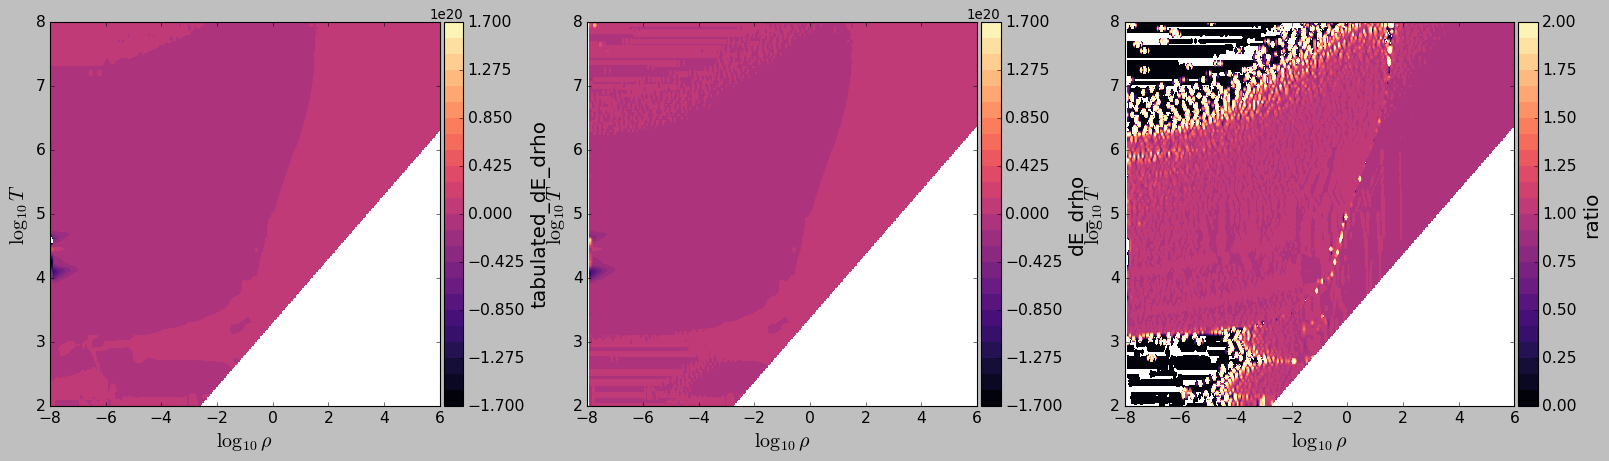

/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1473: UserWarning: The following kwargs were not used by contour: 'shading'
  cs = axes[i,j].contourf(xs[i*nCol + j], ys[i*nCol + j], zs[i*nCol + j], shading='nearest', cmap=cmap[i*nCol + j], levels=levels[i*nCol+j])


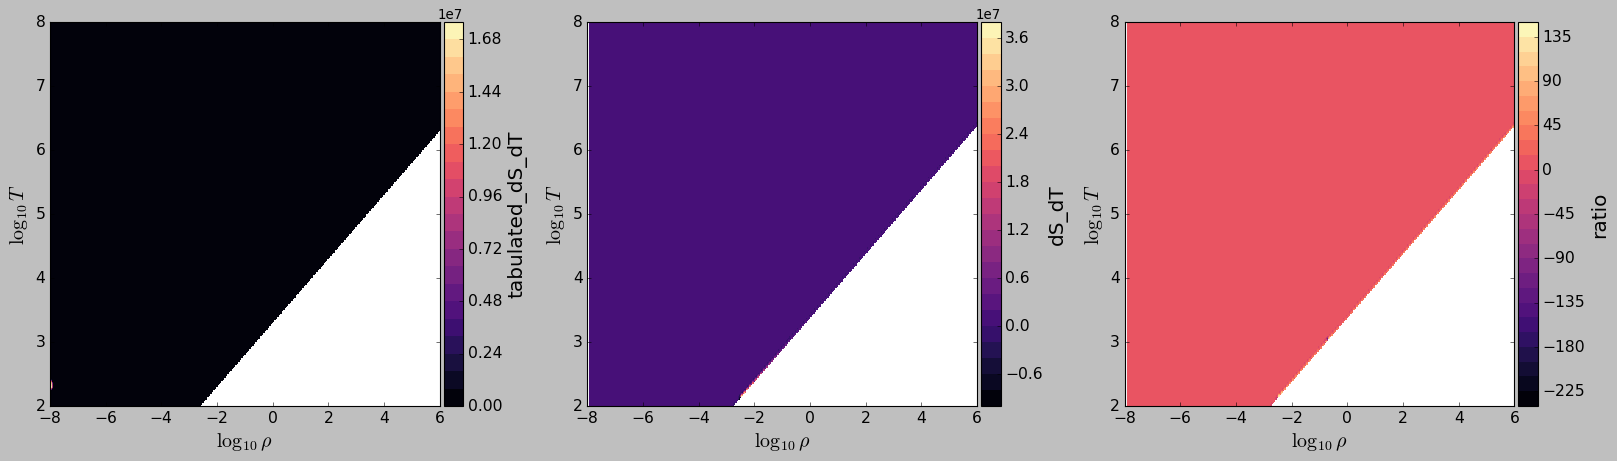

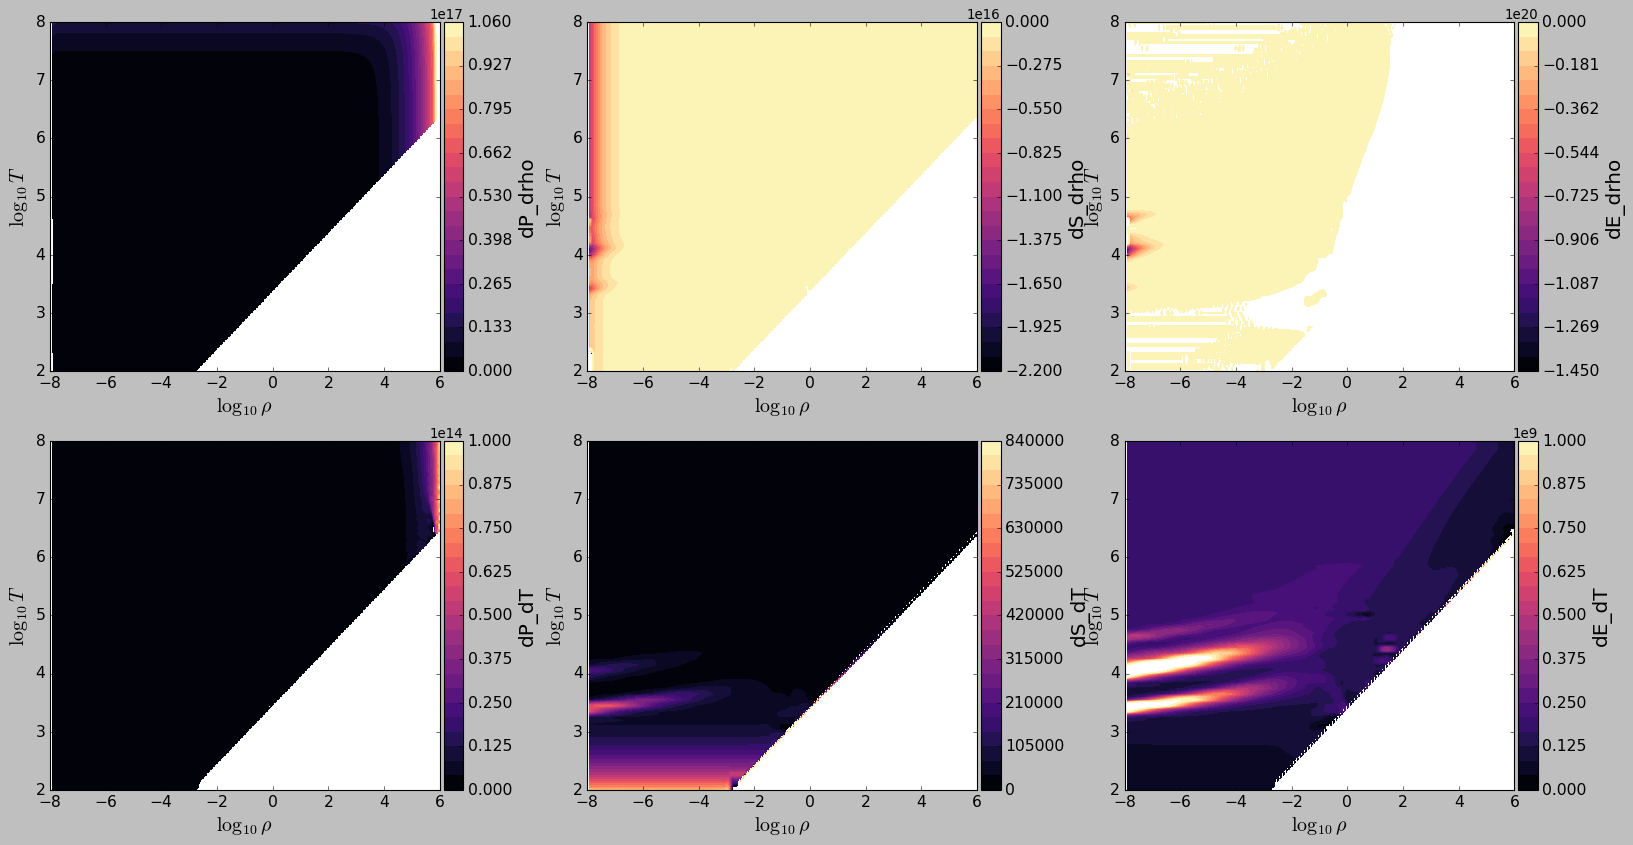

In [7]:

tabulated_dE_drho = orig_tabulated_rhoT[:,:,8]

tabulated_dS_dT = orig_tabulated_rhoT[:,:,9]


dP_drho, dS_drho, dE_drho, dP_dT, dS_dT, dE_dT = meos.finite_difference_PSE(orig_tabulated, 10**orig_tabulated.log10Pgrid, 10**orig_tabulated.log10Sgrid, 10**orig_tabulated.log10Egrid, species = 'H', maskUnphysicalRegion=True, plot=False, savename=None)

meos.contourf_subplots_with_colorbars(nRow=1, nCol=3, 
                                xs=orig_tabulated.log10rhogrid,
                                ys=orig_tabulated.log10Tgrid,
                                zs=[tabulated_dE_drho, dE_drho, dE_drho/tabulated_dE_drho],
                                xlims=(-8,6),
                                ylims=(2,8), 
                                zlims=[(-1.7e20,1.7e20),(-1.7e20,1.7e20),(0,2)],
                                levels=25, 
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['tabulated_dE_drho','dE_drho','ratio'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, savename=None,plot_interpolation_lines=False)

meos.contourf_subplots_with_colorbars(nRow=1, nCol=3, 
                                xs=orig_tabulated.log10rhogrid,
                                ys=orig_tabulated.log10Tgrid,
                                zs=[tabulated_dS_dT, dS_dT, dS_dT/tabulated_dS_dT],
                                xlims=(-8,6),
                                ylims=(2,8), 
                                zlims=None,
                                levels=25, 
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['tabulated_dS_dT','dS_dT','ratio'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, savename=None,plot_interpolation_lines=False)

meos.contourf_subplots_with_colorbars(nRow=2, nCol=3, 
                                xs=orig_tabulated.log10rhogrid,
                                ys=orig_tabulated.log10Tgrid,
                                zs=[dP_drho, dS_drho, dE_drho, dP_dT, dS_dT, dE_dT],
                                xlims=(-8,6),
                                ylims=(2,8), 
                                zlims=[(0.,1.06e17),(-2.2e16,0.),(-1.45e20,0),(0.,1.e14),(0.,8.4e5),(0.,1.e9)],
                                levels=25, 
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['dP_drho','dS_drho','dE_drho','dP_dT','dS_dT','dE_dT'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, savename=None,plot_interpolation_lines=False)


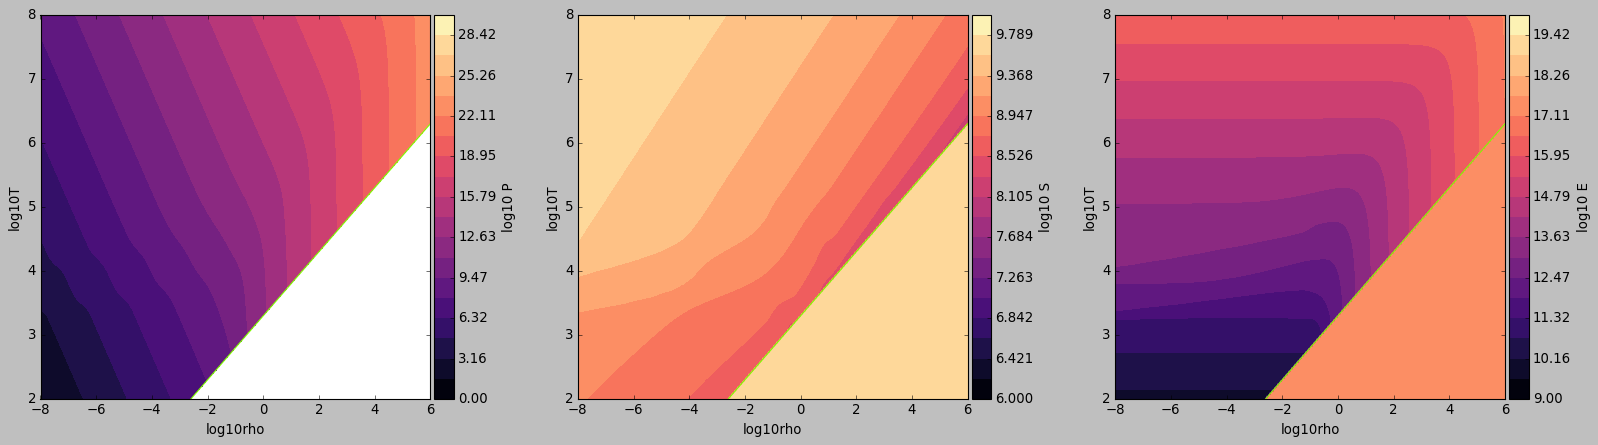

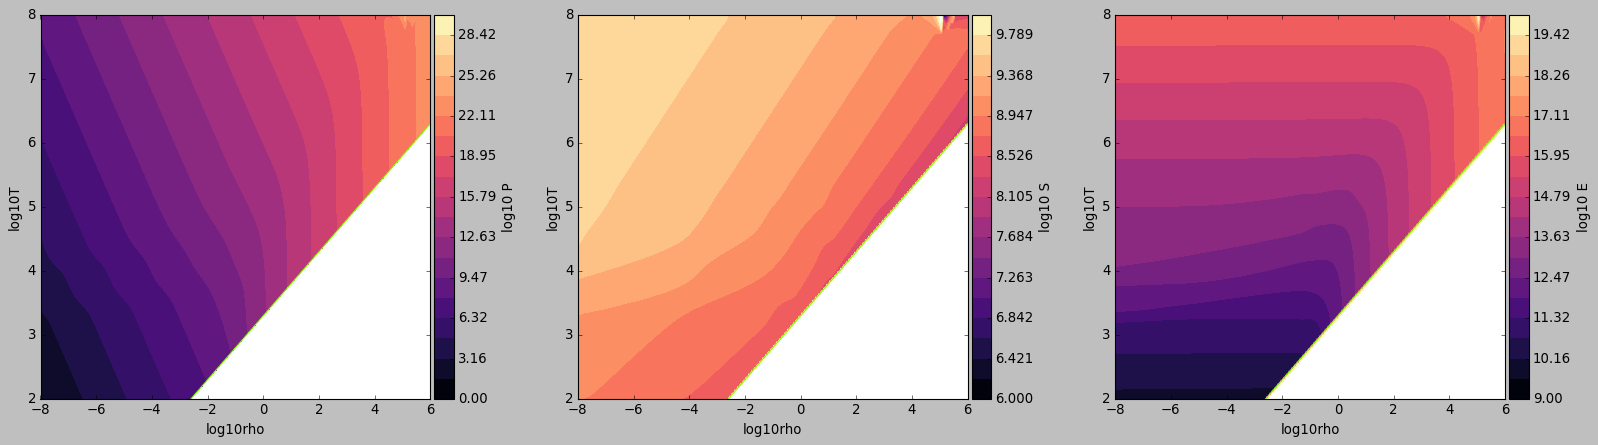

In [20]:
meos.plot_PSE(orig_tabulated, P=10**orig_tabulated.log10Pgrid,S=10**orig_tabulated.log10Sgrid,E=10**orig_tabulated.log10Egrid)

meos.plot_PSE(TC_tabulated, P=10**TC_tabulated.log10Pgrid,S=10**TC_tabulated.log10Sgrid,E=10**TC_tabulated.log10Egrid)

# X = 0.9, Y = 0.1

## Original

In [32]:
orig_tabulated_dpe, orig_tabulated_dse, orig_tabulated_dsp, orig_tabulated_a, orig_tabulated_b, orig_tabulated_c = meos.consistency_metrics(orig_tabulated, P=10**orig_tabulated.log10Pgrid,S=10**orig_tabulated.log10Sgrid,E=10**orig_tabulated.log10Egrid,species='H',maskUnphysicalRegion=True,paperplot=True,plot_tracks=True,savename="./paper_figures/CMS19_orig_meos_implementation_00z100x.png")


In [22]:
#orig_runtime_log10P, orig_runtime_log10S, orig_runtime_log10E, orig_runtime_dpe, orig_runtime_dse, orig_runtime_dsp,  orig_runtime_dpe2, orig_runtime_dse2, orig_runtime_dsp2 = runtime_eos_data("./MESA_runs/eos_CMS19_orig_meos_implementation/00z90x_consistency.dat",X=0.9)


In [23]:
#orig_runtime_dpe_from_meos, orig_runtime_dse_from_meos, orig_runtime_dsp_from_meos, orig_runtime_a_from_meos, orig_runtime_b_from_meos, orig_runtime_c_from_meos = meos.consistency_metrics(orig_tabulated, P=10**orig_runtime_log10P,S=10**orig_runtime_log10S,E=10**orig_runtime_log10E,species='H',maskUnphysicalRegion=True,paperplot=True,plot_tracks=True)


In [24]:
'''
meos.contourf_subplots_with_colorbars(nRow=2, nCol=3, 
                                xs=orig_tabulated.log10rhogrid,
                                ys=orig_tabulated.log10Tgrid,
                                zs=[np.log10(np.abs(orig_runtime_dpe)/np.abs(orig_tabulated_dpe)),
                                    np.log10(np.abs(orig_runtime_dse)/np.abs(orig_tabulated_dse)),
                                    np.log10(np.abs(orig_runtime_dsp)/np.abs(orig_tabulated_dsp)),
                                    np.log10(np.abs(orig_runtime_dpe2)/np.abs(orig_tabulated_dpe)),
                                    np.log10(np.abs(orig_runtime_dse2)/np.abs(orig_tabulated_dse)),
                                    np.log10(np.abs(orig_runtime_dsp2)/np.abs(orig_tabulated_dsp))],
                                xlims=(-8,6),
                                ylims=(2,8), 
                                zlims=(-1,1),
                                levels=25, 
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['dpe/dpe_orig','dse/dse_orig','dsp/dsp_orig','dpe2/dpe_orig','dse2/dse_orig','dsp2/dsp_orig'],
                                cmap='coolwarm', vlines=[2], hlines=[6.6,7.4], otherlines_x=None, otherlines_y=None, savename=None,plot_interpolation_lines=False)
'''

<>:1: SyntaxWarning: invalid escape sequence '\l'
<>:1: SyntaxWarning: invalid escape sequence '\l'
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_38362/4134759538.py:1: SyntaxWarning: invalid escape sequence '\l'
  '''


"\nmeos.contourf_subplots_with_colorbars(nRow=2, nCol=3, \n                                xs=orig_tabulated.log10rhogrid,\n                                ys=orig_tabulated.log10Tgrid,\n                                zs=[np.log10(np.abs(orig_runtime_dpe)/np.abs(orig_tabulated_dpe)),\n                                    np.log10(np.abs(orig_runtime_dse)/np.abs(orig_tabulated_dse)),\n                                    np.log10(np.abs(orig_runtime_dsp)/np.abs(orig_tabulated_dsp)),\n                                    np.log10(np.abs(orig_runtime_dpe2)/np.abs(orig_tabulated_dpe)),\n                                    np.log10(np.abs(orig_runtime_dse2)/np.abs(orig_tabulated_dse)),\n                                    np.log10(np.abs(orig_runtime_dsp2)/np.abs(orig_tabulated_dsp))],\n                                xlims=(-8,6),\n                                ylims=(2,8), \n                                zlims=(-1,1),\n                                levels=25, \n                       

In [25]:
'''
meos.contourf_subplots_with_colorbars(nRow=1, nCol=3, 
                                xs=orig_tabulated.log10rhogrid,
                                ys=orig_tabulated.log10Tgrid,
                                zs=[10**orig_runtime_log10P/10**orig_tabulated.log10Pgrid,
                                    10**orig_runtime_log10S/10**orig_tabulated.log10Sgrid,
                                    10**orig_runtime_log10E/10**orig_tabulated.log10Egrid],
                                xlims=(-8,6),
                                ylims=(2,8), 
                                zlims=(1.-1.e-6,1.+1.e-6),
                                levels=25, 
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['P_at_runtime/P_from_file','S_at_runtime/S_from_file','E_at_runtime/E_from_file'],
                                cmap='coolwarm', vlines=[2], hlines=[6.6,7.4], otherlines_x=None, otherlines_y=None, savename=None,plot_interpolation_lines=False)
'''

<>:1: SyntaxWarning: invalid escape sequence '\l'
<>:1: SyntaxWarning: invalid escape sequence '\l'
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_38362/1768607024.py:1: SyntaxWarning: invalid escape sequence '\l'
  '''


"\nmeos.contourf_subplots_with_colorbars(nRow=1, nCol=3, \n                                xs=orig_tabulated.log10rhogrid,\n                                ys=orig_tabulated.log10Tgrid,\n                                zs=[10**orig_runtime_log10P/10**orig_tabulated.log10Pgrid,\n                                    10**orig_runtime_log10S/10**orig_tabulated.log10Sgrid,\n                                    10**orig_runtime_log10E/10**orig_tabulated.log10Egrid],\n                                xlims=(-8,6),\n                                ylims=(2,8), \n                                zlims=(1.-1.e-6,1.+1.e-6),\n                                levels=25, \n                                xlabels=r'$\\log_{10}\rho$',\n                                ylabels=r'$\\log_{10}T$',\n                                zlabels=['P_at_runtime/P_from_file','S_at_runtime/S_from_file','E_at_runtime/E_from_file'],\n                                cmap='coolwarm', vlines=[2], hlines=[6.6,7.4], otherlines_x

## Thermodyn. consistent version

In [34]:
TC_tabulated_dpe, TC_tabulated_dse, TC_tabulated_dsp, TC_tabulated_a, TC_tabulated_b, TC_tabulated_c = meos.consistency_metrics(TC_tabulated, P=10**TC_tabulated.log10Pgrid,S=10**TC_tabulated.log10Sgrid,E=10**TC_tabulated.log10Egrid,species='H',maskUnphysicalRegion=True,paperplot=True,plot_tracks=True,savename="./paper_figures/CMS19_TC_s=1_00z100x.pdf")


In [27]:
#TC_runtime_log10P, TC_runtime_log10S, TC_runtime_log10E, TC_runtime_dpe, TC_runtime_dse, TC_runtime_dsp,  TC_runtime_dpe2, TC_runtime_dse2, TC_runtime_dsp2, = runtime_eos_data("./MESA_runs/eos_CMS19_TC_s=1/00z90x_consistency.dat",X=0.9)


In [28]:
#TC_runtime_dpe_from_meos, TC_runtime_dse_from_meos, TC_runtime_dsp_from_meos, TC_runtime_a_from_meos, TC_runtime_b_from_meos, TC_runtime_c_from_meos = meos.consistency_metrics(TC_tabulated, P=10**TC_runtime_log10P,S=10**TC_runtime_log10S,E=10**TC_runtime_log10E,species='H',maskUnphysicalRegion=True,paperplot=True,plot_tracks=True)


In [29]:
'''
meos.contourf_subplots_with_colorbars(nRow=2, nCol=3, 
                                xs=TC_tabulated.log10rhogrid,
                                ys=TC_tabulated.log10Tgrid,
                                zs=[np.log10(np.abs(TC_runtime_dpe)/np.abs(TC_tabulated_dpe)),
                                    np.log10(np.abs(TC_runtime_dse)/np.abs(TC_tabulated_dse)),
                                    np.log10(np.abs(TC_runtime_dsp)/np.abs(TC_tabulated_dsp)),
                                    np.log10(np.abs(TC_runtime_dpe2)/np.abs(TC_tabulated_dpe)),
                                    np.log10(np.abs(TC_runtime_dse2)/np.abs(TC_tabulated_dse)),
                                    np.log10(np.abs(TC_runtime_dsp2)/np.abs(TC_tabulated_dsp))],
                                xlims=(-8,6),
                                ylims=(2,8), 
                                zlims=(-2,2),
                                levels=25, 
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['dpe/dpe_orig','dse/dse_orig','dsp/dsp_orig','dpe2/dpe_orig','dse2/dse_orig','dsp2/dsp_orig'],
                                cmap='coolwarm', vlines=[2], hlines=[6.6,7.4], otherlines_x=None, otherlines_y=None, savename=None,plot_interpolation_lines=False)
'''

<>:1: SyntaxWarning: invalid escape sequence '\l'
<>:1: SyntaxWarning: invalid escape sequence '\l'
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_38362/1600410218.py:1: SyntaxWarning: invalid escape sequence '\l'
  '''


"\nmeos.contourf_subplots_with_colorbars(nRow=2, nCol=3, \n                                xs=TC_tabulated.log10rhogrid,\n                                ys=TC_tabulated.log10Tgrid,\n                                zs=[np.log10(np.abs(TC_runtime_dpe)/np.abs(TC_tabulated_dpe)),\n                                    np.log10(np.abs(TC_runtime_dse)/np.abs(TC_tabulated_dse)),\n                                    np.log10(np.abs(TC_runtime_dsp)/np.abs(TC_tabulated_dsp)),\n                                    np.log10(np.abs(TC_runtime_dpe2)/np.abs(TC_tabulated_dpe)),\n                                    np.log10(np.abs(TC_runtime_dse2)/np.abs(TC_tabulated_dse)),\n                                    np.log10(np.abs(TC_runtime_dsp2)/np.abs(TC_tabulated_dsp))],\n                                xlims=(-8,6),\n                                ylims=(2,8), \n                                zlims=(-2,2),\n                                levels=25, \n                                xlabels=r'$\\log_{1

In [30]:
'''
meos.contourf_subplots_with_colorbars(nRow=1, nCol=3, 
                                xs=TC_tabulated.log10rhogrid,
                                ys=TC_tabulated.log10Tgrid,
                                zs=[10**TC_runtime_log10P/10**TC_tabulated.log10Pgrid,
                                    10**TC_runtime_log10S/10**TC_tabulated.log10Sgrid,
                                    10**TC_runtime_log10E/10**TC_tabulated.log10Egrid],
                                xlims=(-8,6),
                                ylims=(2,8), 
                                zlims=(1.-1.e-6,1.+1.e-6),
                                levels=25, 
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['P_at_runtime/P_from_file','S_at_runtime/S_from_file','E_at_runtime/E_from_file'],
                                cmap='coolwarm', vlines=[2], hlines=[6.6,7.4], otherlines_x=None, otherlines_y=None, savename=None,plot_interpolation_lines=False)
'''

<>:1: SyntaxWarning: invalid escape sequence '\l'
<>:1: SyntaxWarning: invalid escape sequence '\l'
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_38362/2809916305.py:1: SyntaxWarning: invalid escape sequence '\l'
  '''


"\nmeos.contourf_subplots_with_colorbars(nRow=1, nCol=3, \n                                xs=TC_tabulated.log10rhogrid,\n                                ys=TC_tabulated.log10Tgrid,\n                                zs=[10**TC_runtime_log10P/10**TC_tabulated.log10Pgrid,\n                                    10**TC_runtime_log10S/10**TC_tabulated.log10Sgrid,\n                                    10**TC_runtime_log10E/10**TC_tabulated.log10Egrid],\n                                xlims=(-8,6),\n                                ylims=(2,8), \n                                zlims=(1.-1.e-6,1.+1.e-6),\n                                levels=25, \n                                xlabels=r'$\\log_{10}\rho$',\n                                ylabels=r'$\\log_{10}T$',\n                                zlabels=['P_at_runtime/P_from_file','S_at_runtime/S_from_file','E_at_runtime/E_from_file'],\n                                cmap='coolwarm', vlines=[2], hlines=[6.6,7.4], otherlines_x=None, otherline

# look at MESA default quantities

In [119]:
compstr = "00z80x"
XX = 0.8
YY = 0.2
ZZ = 0.0

mesa_runtime_lnP = np.genfromtxt("/Users/emily/mesa-24.08.1/eos/plotter/MESAdefault_lnPgas_{0}.dat".format(compstr),skip_header=4)
mesa_runtime_log10P = (mesa_runtime_lnP[:,2].reshape(281,121))/np.log(10)

mesa_runtime_lnS = np.genfromtxt("/Users/emily/mesa-24.08.1/eos/plotter/MESAdefault_lnS_{0}.dat".format(compstr),skip_header=4)
mesa_runtime_log10S = (mesa_runtime_lnS[:,2].reshape(281,121))/np.log(10)

mesa_runtime_lnE = np.genfromtxt("/Users/emily/mesa-24.08.1/eos/plotter/MESAdefault_lnE_{0}.dat".format(compstr),skip_header=4)
mesa_runtime_log10E = (mesa_runtime_lnE[:,2].reshape(281,121))/np.log(10)

mesa_runtime_log10rho = np.genfromtxt("/Users/emily/mesa-24.08.1/eos/plotter/MESAdefault_lnPgas_{0}.dat".format(compstr),skip_header=4)[:,1].reshape(281,121)
mesa_runtime_log10T = np.genfromtxt("/Users/emily/mesa-24.08.1/eos/plotter/MESAdefault_lnPgas_{0}.dat".format(compstr),skip_header=4)[:,0].reshape(281,121)

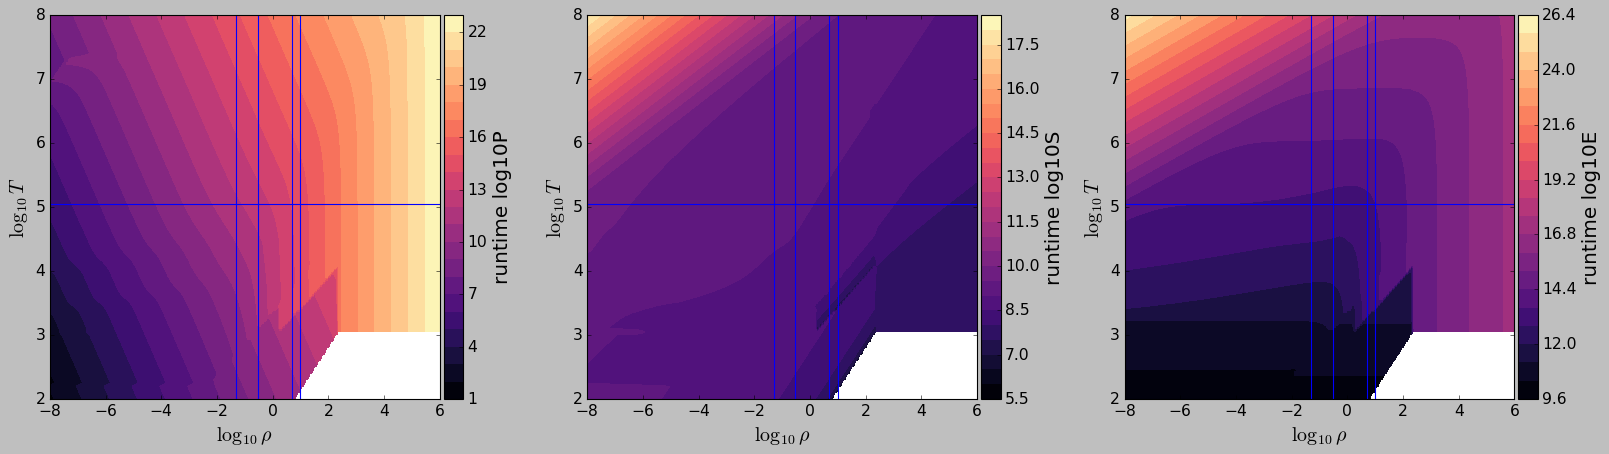

In [120]:
meos.contourf_subplots_with_colorbars(nRow=1, nCol=3, 
                                xs=mesa_runtime_log10rho,
                                ys=mesa_runtime_log10T,
                                zs=[mesa_runtime_log10P,mesa_runtime_log10S,mesa_runtime_log10E],
                                xlims=(-8,6),
                                ylims=(2,8), 
                                zlims=None,
                                levels=25, 
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['runtime log10P','runtime log10S','runtime log10E'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, savename=None)


In [121]:
# now compare to P,S,E read in directly from MESA table file
MESAdefault_tabular_QT = meos.read_MESAtable("/Users/emily/mesa-24.08.1/data/eosDT_data/mesa-eosDT_{0}.data".format(compstr))
print(np.shape(MESAdefault_tabular_QT))

(527, 306, 19)


In [122]:
print(MESAdefault_z00x80_QT[:,:,0])
#print(MESAdefault_z00x80_QT[:,:,1])
#print(MESAdefault_z00x80_QT[:,:,2])
#print(MESAdefault_z00x80_QT[:,:,3])
print(MESAdefault_z00x80_QT[:,:,-2])
print(MESAdefault_z00x80_QT[:,:,-1])

[[2.1  2.12 2.14 ... 8.16 8.18 8.2 ]
 [2.1  2.12 2.14 ... 8.16 8.18 8.2 ]
 [2.1  2.12 2.14 ... 8.16 8.18 8.2 ]
 ...
 [2.1  2.12 2.14 ... 8.16 8.18 8.2 ]
 [2.1  2.12 2.14 ... 8.16 8.18 8.2 ]
 [2.1  2.12 2.14 ... 8.16 8.18 8.2 ]]
[[-10.09 -10.09 -10.09 ... -10.09 -10.09 -10.09]
 [-10.06 -10.06 -10.06 ... -10.06 -10.06 -10.06]
 [-10.03 -10.03 -10.03 ... -10.03 -10.03 -10.03]
 ...
 [  5.63   5.63   5.63 ...   5.63   5.63   5.63]
 [  5.66   5.66   5.66 ...   5.66   5.66   5.66]
 [  5.69   5.69   5.69 ...   5.69   5.69   5.69]]
[[-17.89 -17.85 -17.81 ...  -5.77  -5.73  -5.69]
 [-17.86 -17.82 -17.78 ...  -5.74  -5.7   -5.66]
 [-17.83 -17.79 -17.75 ...  -5.71  -5.67  -5.63]
 ...
 [ -2.17  -2.13  -2.09 ...   9.95   9.99  10.03]
 [ -2.14  -2.1   -2.06 ...   9.98  10.02  10.06]
 [ -2.11  -2.07  -2.03 ...  10.01  10.05  10.09]]


In [123]:
MESAdefault_tabular_rhoT, MESAdefault_tabular = meos.reshapeQTgrid(MESAdefault_tabular_QT,lower_logRho_bound=-8,upper_logRho_bound=6,rounding=2)
MESAdefault_tabular.X = XX
MESAdefault_tabular.Y = YY
MESAdefault_tabular.Z = ZZ
MESAdefault_tabular.compute_atomic_number()

In [124]:
def fill_in_nans_newrhoT(old_rhoT_grid, old_rhoT_table, new_rhoT_table, fill_value=np.nan):
    """
    fill in nans & infs in chosen grid belonging to (rho,T) parameterized table
    """

    nonans = np.isfinite(old_rhoT_grid)
    
    Ts = np.ravel(old_rhoT_table.log10Tgrid[nonans])
    rhos = np.ravel(old_rhoT_table.log10rhogrid[nonans])
    coords = np.vstack((Ts,rhos)).T
    
    
    values = np.ravel(old_rhoT_grid[nonans])
    
    interp_fn = interpolate.LinearNDInterpolator(coords, values, fill_value=fill_value)
    
    interp_grid = interp_fn(new_rhoT_table.log10Tgrid, new_rhoT_table.log10rhogrid)

    return interp_grid


In [125]:
# interpolate to get back to same rho,T grid as in plotter
MESAdefault_tabular_interpolated = meos.simple_table()
MESAdefault_tabular_interpolated.log10Tgrid = mesa_runtime_log10T
MESAdefault_tabular_interpolated.log10rhogrid = mesa_runtime_log10rho
MESAdefault_tabular_interpolated.log10Pgrid = fill_in_nans_newrhoT(MESAdefault_tabular.log10Pgrid,MESAdefault_tabular,MESAdefault_tabular_interpolated)
MESAdefault_tabular_interpolated.log10Sgrid = fill_in_nans_newrhoT(MESAdefault_tabular.log10Sgrid,MESAdefault_tabular,MESAdefault_tabular_interpolated)
MESAdefault_tabular_interpolated.log10Egrid = fill_in_nans_newrhoT(MESAdefault_tabular.log10Egrid,MESAdefault_tabular,MESAdefault_tabular_interpolated)

MESAdefault_tabular_interpolated.X = XX
MESAdefault_tabular_interpolated.Y = YY
MESAdefault_tabular_interpolated.Z = ZZ
MESAdefault_tabular_interpolated.compute_atomic_number()

In [126]:
print(np.shape(MESAdefault_tabular_interpolated.log10Tgrid))

(281, 121)


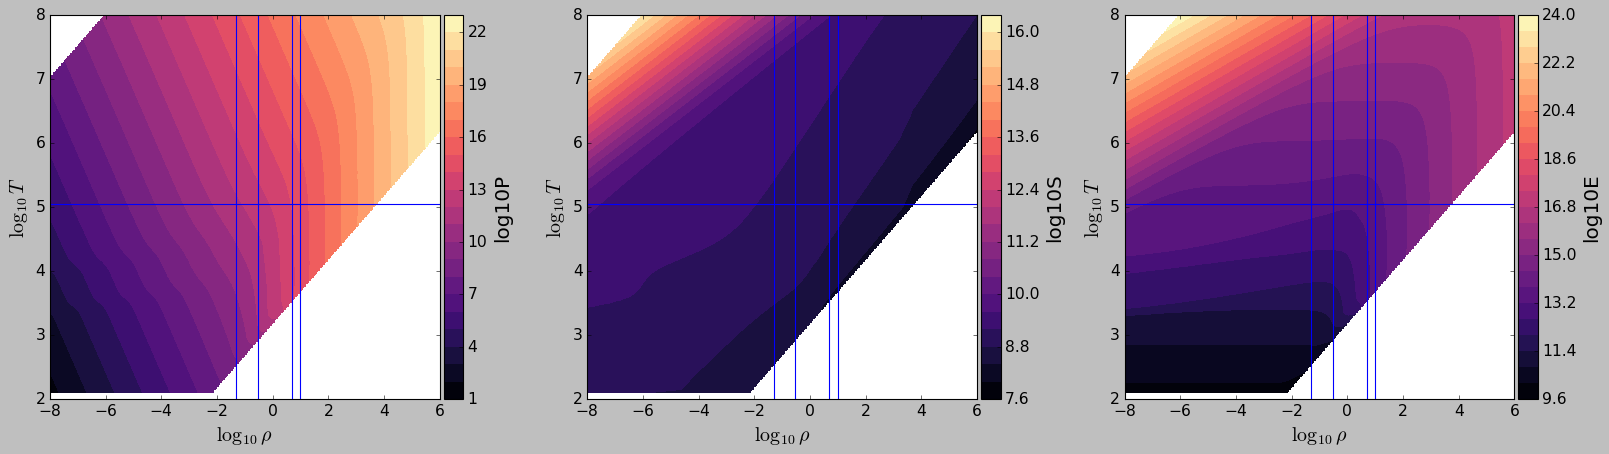

In [127]:
meos.contourf_subplots_with_colorbars(nRow=1, nCol=3, 
                                xs=MESAdefault_tabular_interpolated.log10rhogrid,
                                ys=MESAdefault_tabular_interpolated.log10Tgrid,
                                zs=[MESAdefault_tabular_interpolated.log10Pgrid,MESAdefault_tabular_interpolated.log10Sgrid,MESAdefault_tabular_interpolated.log10Egrid],
                                xlims=(-8,6),
                                ylims=(2,8), 
                                zlims=None,
                                levels=25, 
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['log10P','log10S','log10E'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, savename=None)


In [128]:
# Look at fractional difference

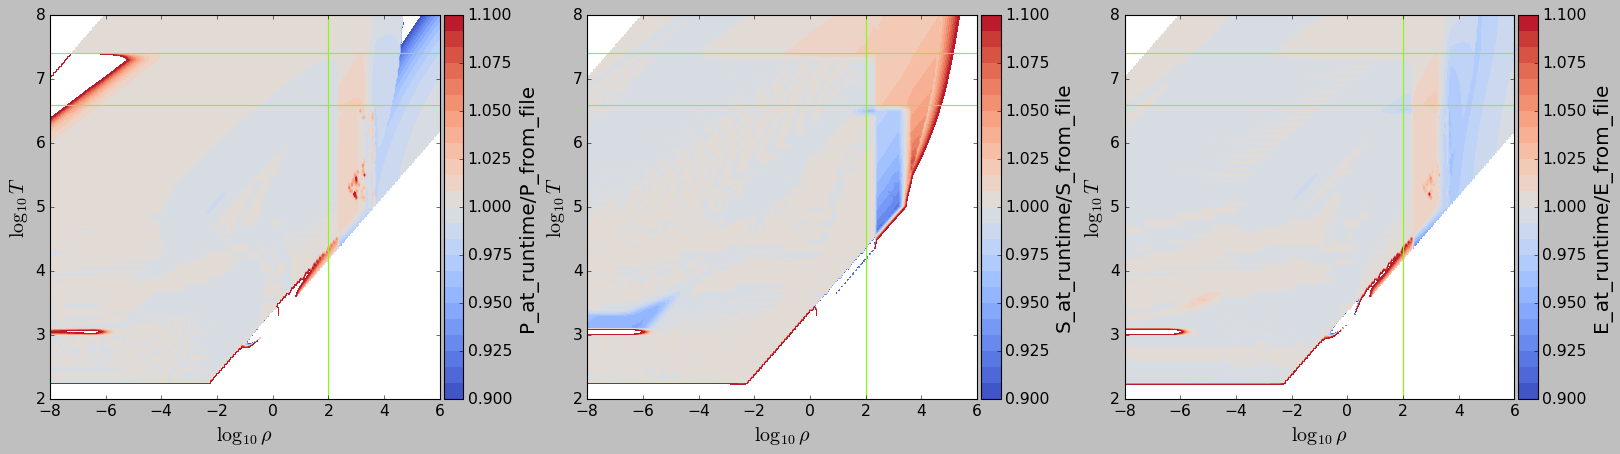

In [129]:
meos.contourf_subplots_with_colorbars(nRow=1, nCol=3, 
                                xs=MESAdefault_tabular_interpolated.log10rhogrid,
                                ys=MESAdefault_tabular_interpolated.log10Tgrid,
                                zs=[10**mesa_runtime_log10P/10**MESAdefault_tabular_interpolated.log10Pgrid,
                                    10**mesa_runtime_log10S/10**MESAdefault_tabular_interpolated.log10Sgrid,
                                    10**mesa_runtime_log10E/10**MESAdefault_tabular_interpolated.log10Egrid],
                                xlims=(-8,6),
                                ylims=(2,8), 
                                zlims=(0.9,1.1),
                                levels=25, 
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['P_at_runtime/P_from_file','S_at_runtime/S_from_file','E_at_runtime/E_from_file'],
                                cmap='coolwarm', vlines=[2], hlines=[6.6,7.4], otherlines_x=None, otherlines_y=None, savename=None,plot_interpolation_lines=False)


# Protosolar composition

In [15]:
compstr = 'protosolar'
XX = 0.706
YY = 0.277
ZZ = 0.017

orig_tabulated_QT = meos.read_MESAtable("../meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend_{0}.data".format(compstr))

orig_tabulated_rhoT, orig_tabulated = meos.reshapeQTgrid(orig_tabulated_QT,lower_logRho_bound=-8,upper_logRho_bound=6,rounding=2)
orig_tabulated.X = XX
orig_tabulated.Y = YY
orig_tabulated.Z = ZZ
orig_tabulated.compute_atomic_number()


TC_tabulated_QT = meos.read_MESAtable("../meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend-TC_s=1_{0}.data".format(compstr))

TC_tabulated_rhoT, TC_tabulated = meos.reshapeQTgrid(TC_tabulated_QT,lower_logRho_bound=-8,upper_logRho_bound=6,rounding=2)
TC_tabulated.X = XX
TC_tabulated.Y = YY
TC_tabulated.Z = ZZ
TC_tabulated.compute_atomic_number()

## Original

/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1846: RuntimeWarning: divide by zero encountered in divide
  dse = (T * (dS_dT/dE_dT)) - 1.0
/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1847: RuntimeWarning: divide by zero encountered in divide
  dsp = (-1.0 * rho**2 * (dS_drho/dP_dT)) - 1.0
/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1860: RuntimeWarning: invalid value encountered in multiply
  b = -1.0 * dE_dT * dse
/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1861: RuntimeWarning: invalid value encountered in multiply
  c = (1.0/rho**2) * dP_dT * dsp


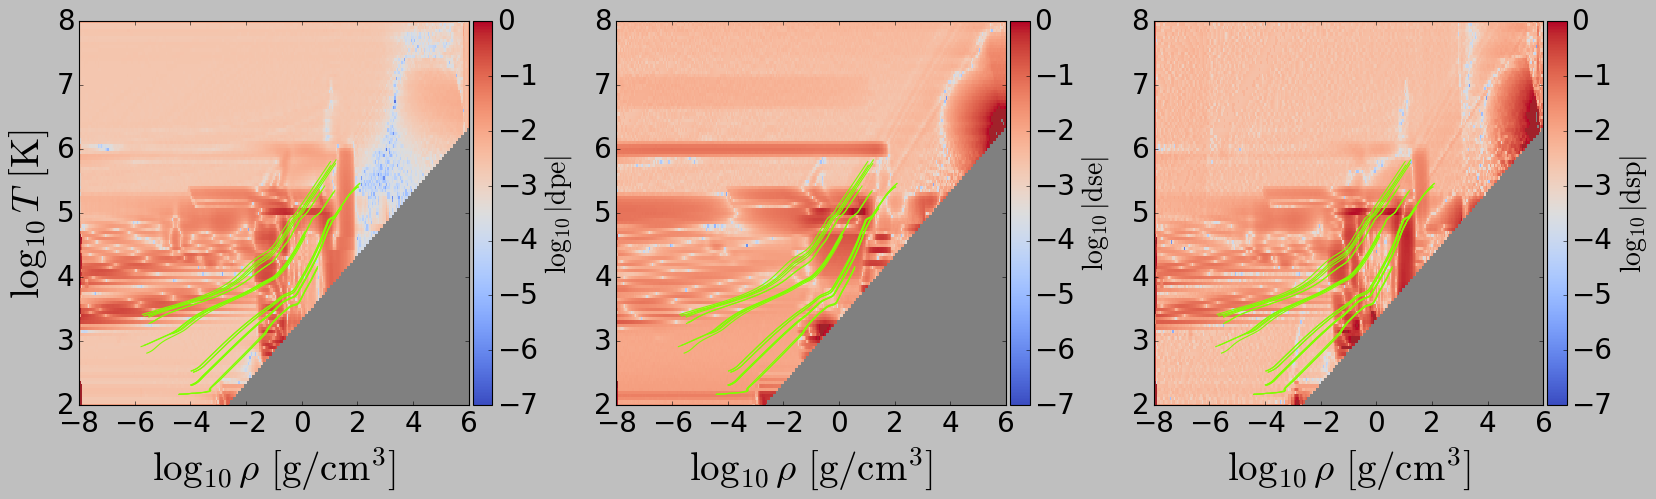

In [16]:
orig_tabulated_dpe, orig_tabulated_dse, orig_tabulated_dsp, orig_tabulated_a, orig_tabulated_b, orig_tabulated_c = meos.consistency_metrics(orig_tabulated, P=10**orig_tabulated.log10Pgrid,S=10**orig_tabulated.log10Sgrid,E=10**orig_tabulated.log10Egrid,species='H',maskUnphysicalRegion=True,paperplot=True,plot_tracks=True)


/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_30603/3641000452.py:87: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = copy.copy(mpl.cm.get_cmap("coolwarm"))


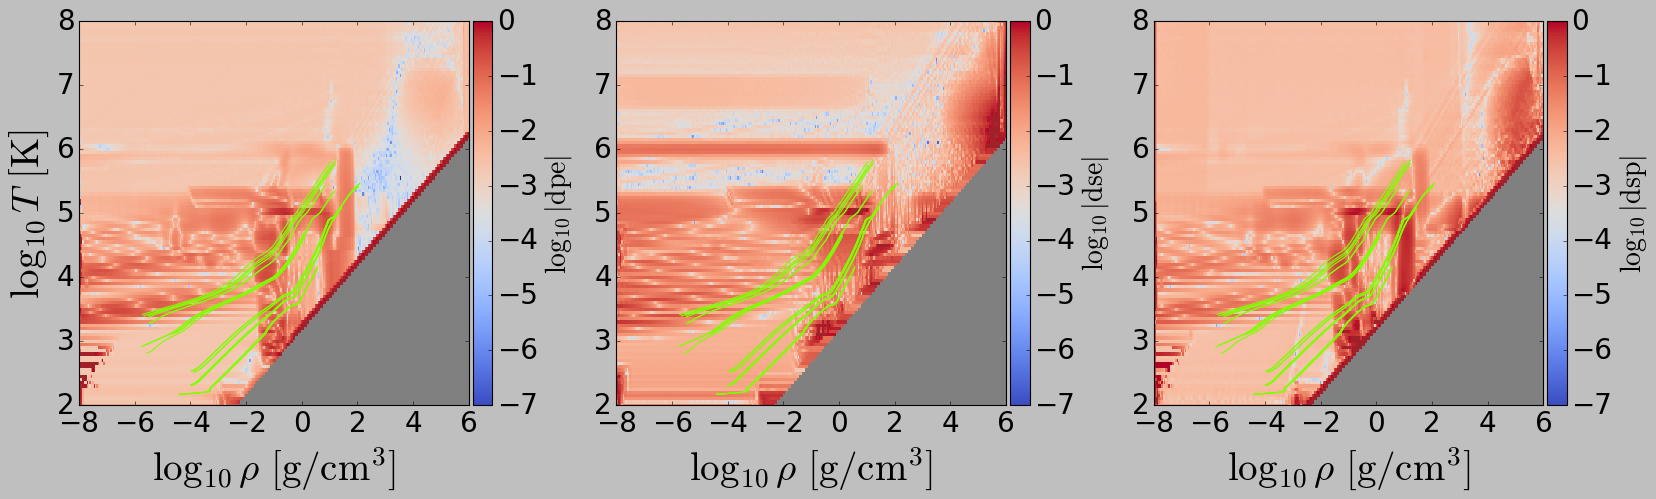

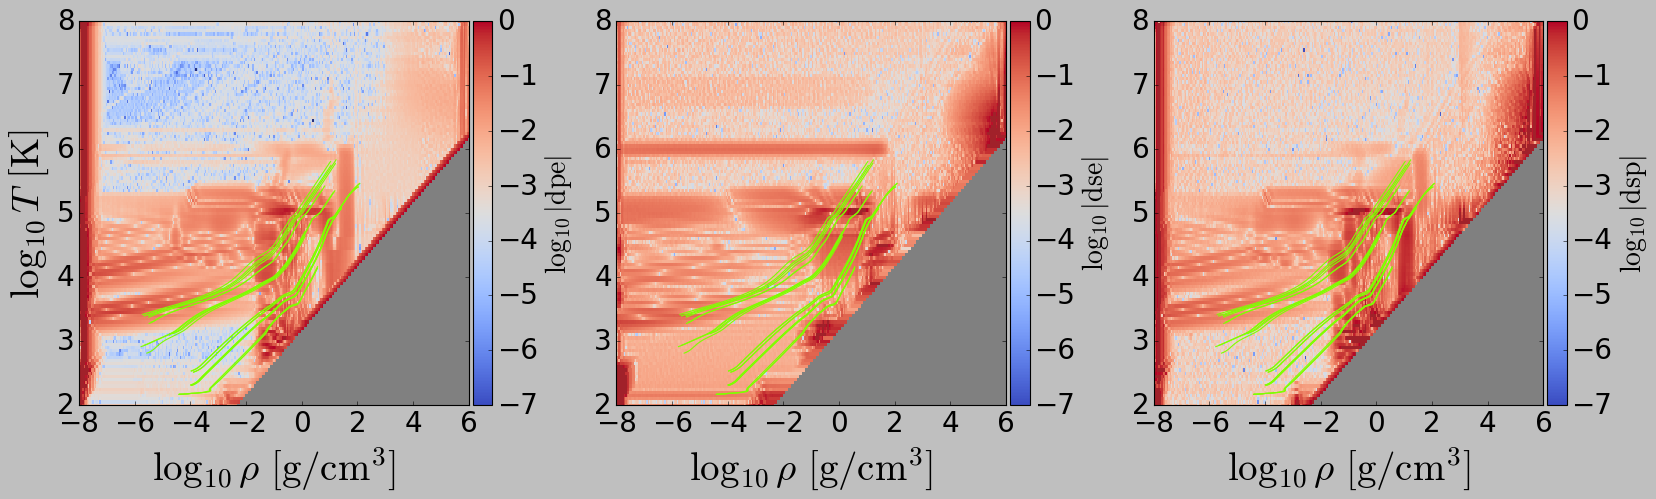

In [17]:
orig_runtime_log10P, orig_runtime_log10S, orig_runtime_log10E, orig_runtime_dpe, orig_runtime_dse, orig_runtime_dsp,  orig_runtime_dpe2, orig_runtime_dse2, orig_runtime_dsp2 = runtime_eos_data("./MESA_runs/eos_CMS19_orig_meos_implementation/protosolar_consistency.dat",X=0.9)


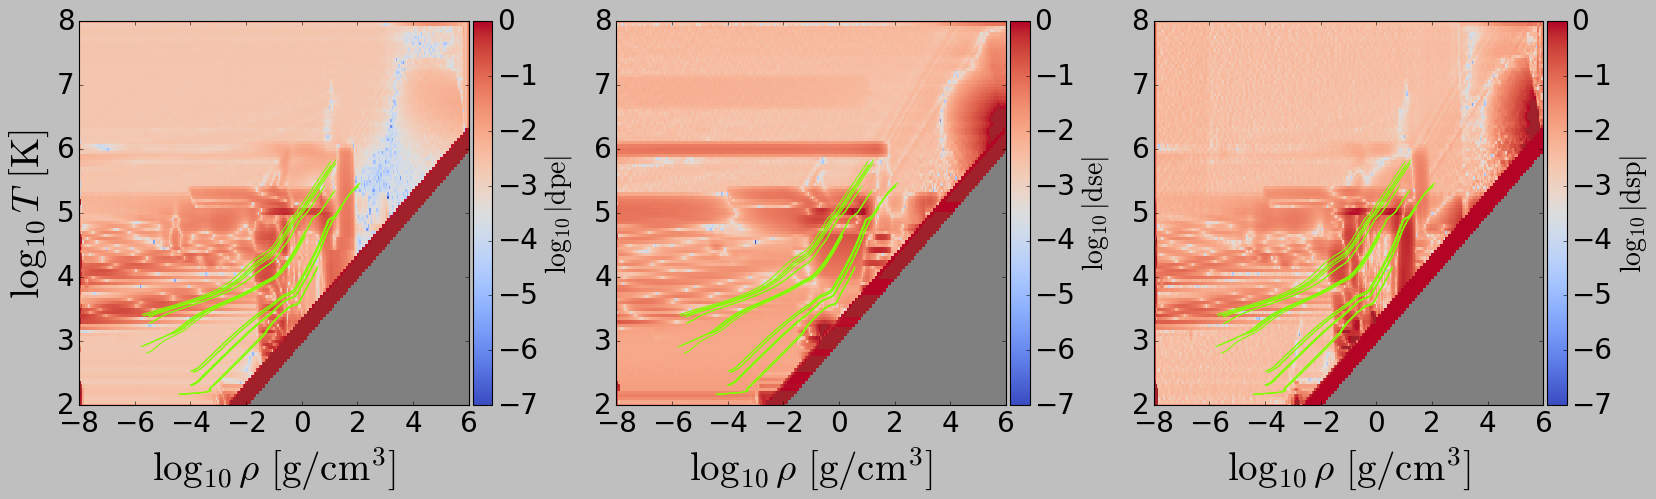

In [18]:
orig_runtime_dpe_from_meos, orig_runtime_dse_from_meos, orig_runtime_dsp_from_meos, orig_runtime_a_from_meos, orig_runtime_b_from_meos, orig_runtime_c_from_meos = meos.consistency_metrics(orig_tabulated, P=10**orig_runtime_log10P,S=10**orig_runtime_log10S,E=10**orig_runtime_log10E,species='H',maskUnphysicalRegion=True,paperplot=True,plot_tracks=True)


## TC

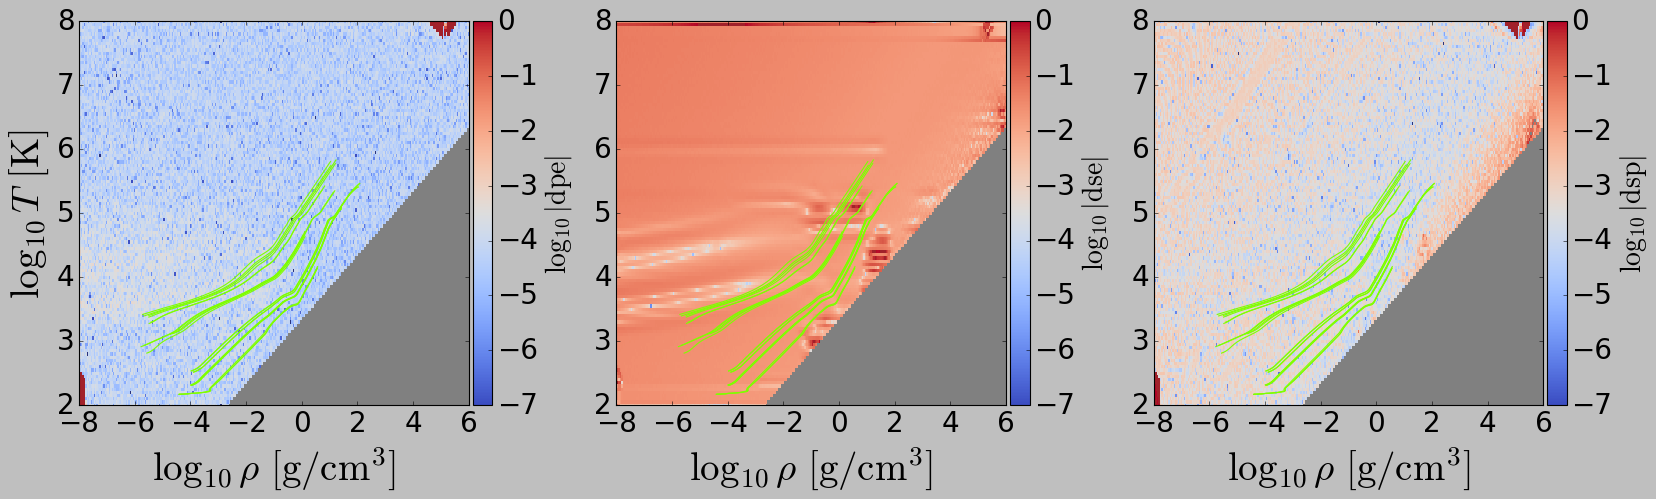

In [20]:
TC_tabulated_dpe, TC_tabulated_dse, TC_tabulated_dsp, TC_tabulated_a, TC_tabulated_b, TC_tabulated_c = meos.consistency_metrics(TC_tabulated, P=10**TC_tabulated.log10Pgrid,S=10**TC_tabulated.log10Sgrid,E=10**TC_tabulated.log10Egrid,species='H',maskUnphysicalRegion=True,paperplot=True,plot_tracks=True)


/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_7408/3207500918.py:87: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = copy.copy(mpl.cm.get_cmap("coolwarm"))


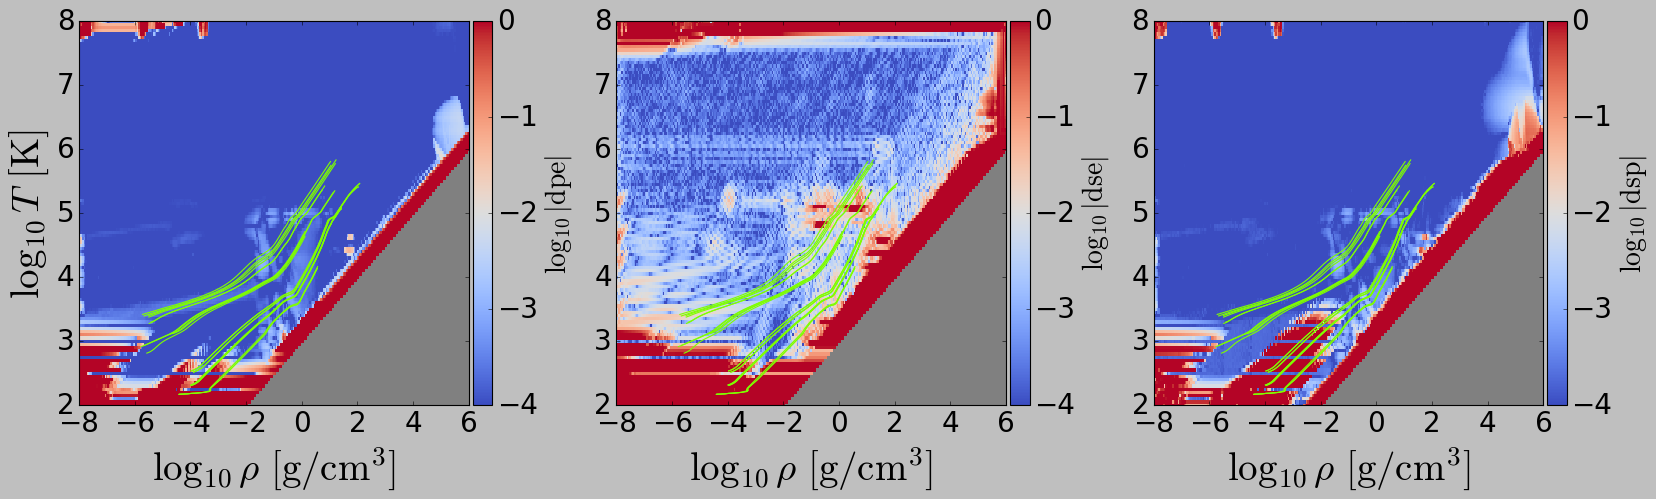

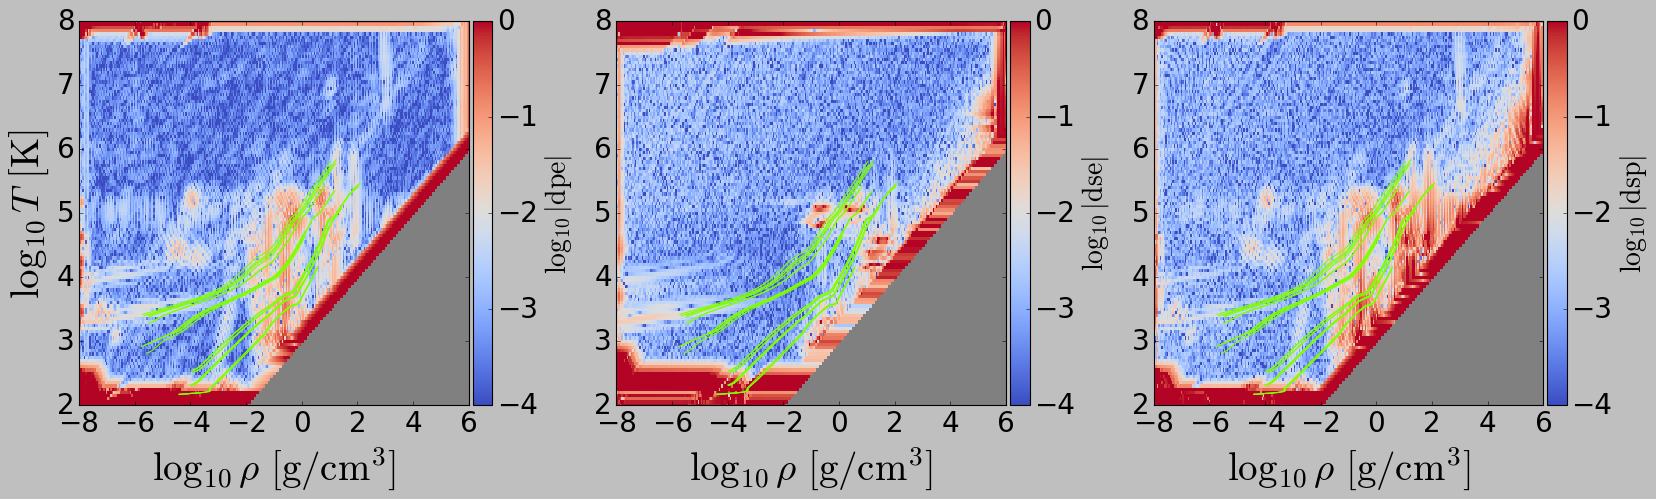

In [18]:
 TC_runtime_log10P, TC_runtime_log10S, TC_runtime_log10E, TC_runtime_dpe, TC_runtime_dse, TC_runtime_dsp,  TC_runtime_dpe2, TC_runtime_dse2, TC_runtime_dsp2, = runtime_eos_data("./MESA_runs/eos_CMS19_TC_s=1/protosolar_consistency.dat",X=0.706)


/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_66101/3207500918.py:87: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = copy.copy(mpl.cm.get_cmap("coolwarm"))


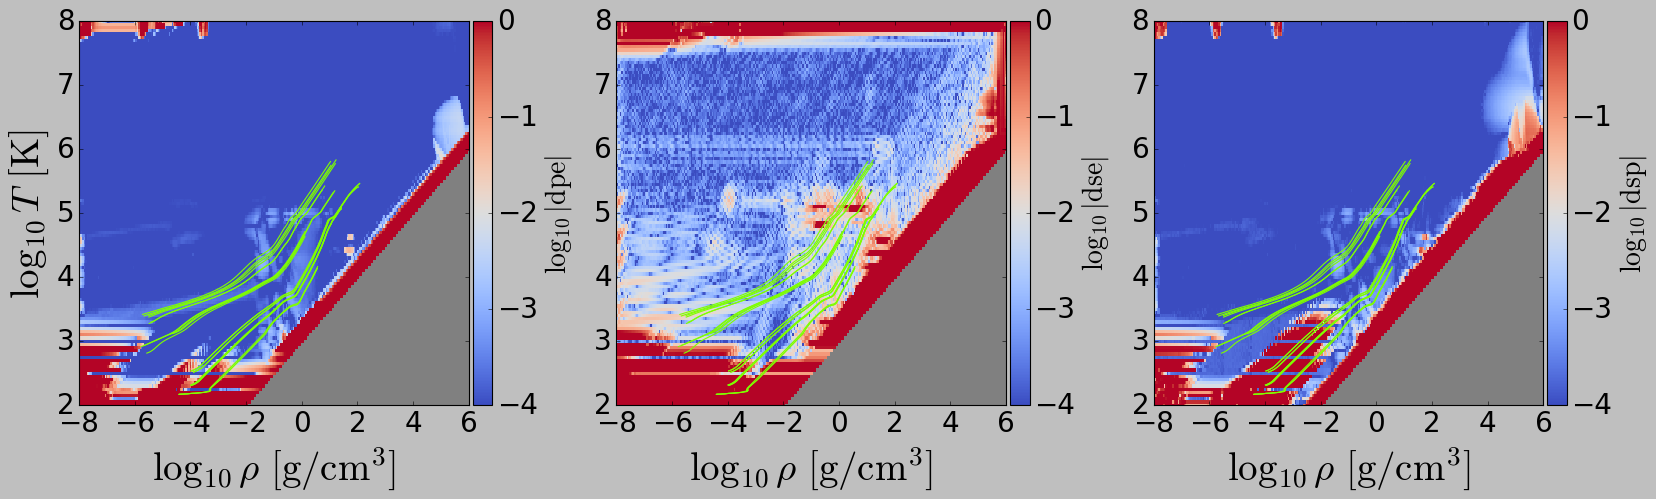

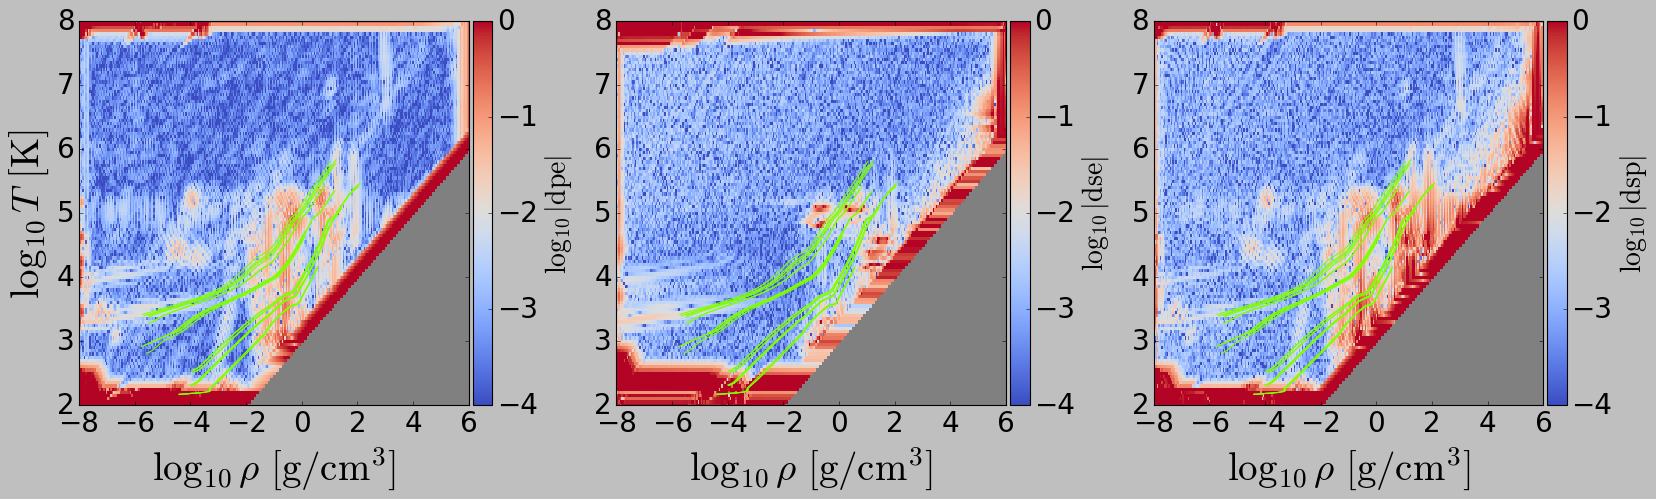

1.294
1.8820000000000001


In [7]:
compstr = 'protosolar'
XX = 0.706
YY = 0.277
ZZ = 0.017

orig_tabulated_QT = meos.read_MESAtable("../meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend_{0}.data".format(compstr))

orig_tabulated_rhoT, orig_tabulated = meos.reshapeQTgrid(orig_tabulated_QT,lower_logRho_bound=-8,upper_logRho_bound=6,rounding=2)
orig_tabulated.X = XX
orig_tabulated.Y = YY
orig_tabulated.Z = ZZ
orig_tabulated.compute_atomic_number()


TC_tabulated_QT = meos.read_MESAtable("../meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend-TC_s=2_{0}.data".format(compstr))

TC_tabulated_rhoT, TC_tabulated = meos.reshapeQTgrid(TC_tabulated_QT,lower_logRho_bound=-8,upper_logRho_bound=6,rounding=2)
TC_tabulated.X = XX
TC_tabulated.Y = YY
TC_tabulated.Z = ZZ
TC_tabulated.compute_atomic_number()

TC_runtime_log10P, TC_runtime_log10S, TC_runtime_log10E, TC_runtime_dpe, TC_runtime_dse, TC_runtime_dsp,  TC_runtime_dpe2, TC_runtime_dse2, TC_runtime_dsp2, = runtime_eos_data("./MESA_runs/eos_CMS19_TC_s=1/protosolar_consistency.dat",X=0.706)


TC_runtime = meos.simple_table()
TC_runtime.log10rhogrid = TC_tabulated.log10rhogrid
TC_runtime.log10Tgrid = TC_tabulated.log10Tgrid
TC_runtime.log10Pgrid = TC_runtime_log10P
TC_runtime.log10Sgrid = TC_runtime_log10S
TC_runtime.log10Egrid = TC_runtime_log10E
TC_runtime.X =0.706
TC_runtime.Y =0.277
TC_runtime.Z = 0.017
TC_runtime.compute_atomic_number()
print(TC_runtime.atomic_number)
print(TC_runtime.mass_number)
# to avoid plotting bad diagonal stripe
TC_runtime.atomic_number = 4.6

TC_runtime_dpe_meos, TC_runtime_dse_meos, TC_runtime_dsp_meos, TC_runtime_a_meos, TC_runtime_b_meos, TC_runtime_c_meos  = meos.consistency_metrics(TC_runtime, P=10**TC_runtime_log10P,S=10**TC_runtime_log10S,E=10**TC_runtime_log10E,species='He',maskUnphysicalRegion=True,paperplot=True,plot_tracks=True,savename='./paper_figures/protosolar_comp_TC_pre-upscaling.png')


upscale_rhoT(TC_runtime,upscale_factor=10,plot_tracks=True,savename="./paper_figures/protosolar_comp_TC_upscaledx10.png")

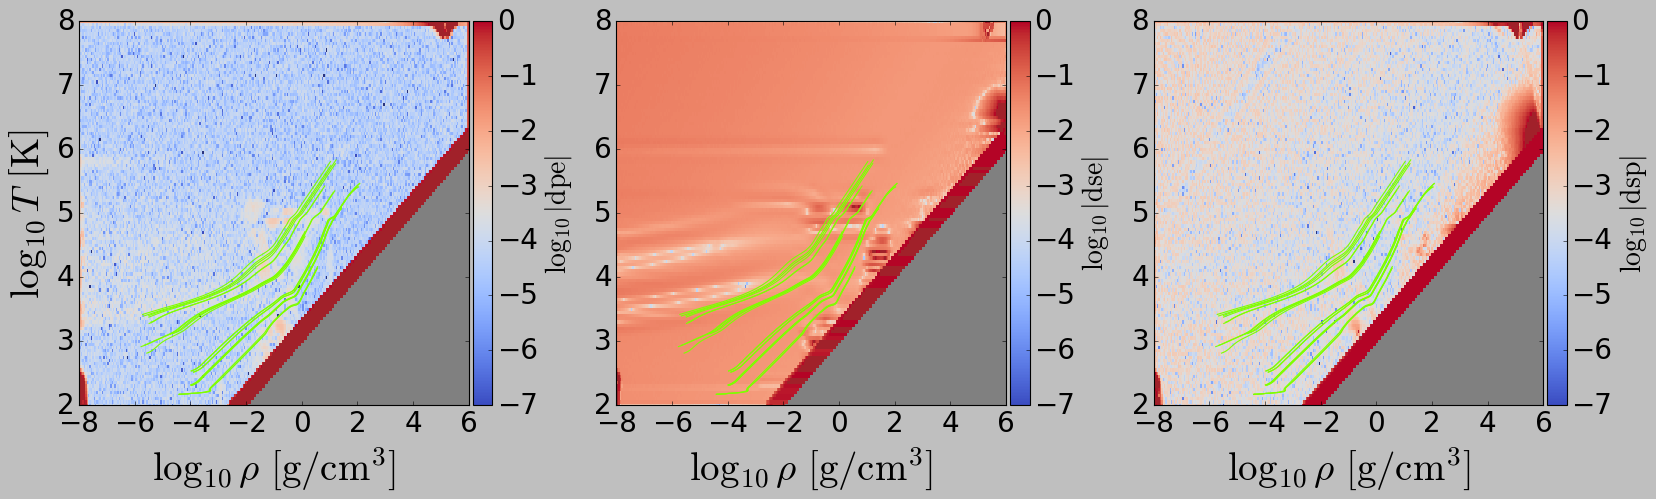

In [22]:
TC_runtime_dpe_from_meos, TC_runtime_dse_from_meos, TC_runtime_dsp_from_meos, TC_runtime_a_from_meos, TC_runtime_b_from_meos, TC_runtime_c_from_meos = meos.consistency_metrics(TC_tabulated, P=10**TC_runtime_log10P,S=10**TC_runtime_log10S,E=10**TC_runtime_log10E,species='H',maskUnphysicalRegion=True,paperplot=True,plot_tracks=True)
